In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import pandas as pd
import os
import torch
import glob
import re
from typing import Dict, Iterable, List, Optional, Tuple


# original data

In [3]:
DATAPATH_BASE = '../../data/MW/'
FITS_PATH     = os.path.join(DATAPATH_BASE, 'fcnm_RHI_z.fits')
CSV_DIR       = os.path.join(DATAPATH_BASE, 'syn_HI_spec_z')


def load_spectra(data_path):
    files = sorted(glob.glob(os.path.join(data_path, "*.csv.gz")))
    tb_spectra = []
    tau = []
    for fp in files:
        df = pd.read_csv(fp)
        tb_spectra.append(df.iloc[:, 1].values.astype(np.float32))   # TB column
        tau.append(df.iloc[:, 2].values.astype(np.float32))      # tau column
    return np.asarray(tb_spectra),np.asarray(tau)  # (N, 201)

In [11]:
#files1 = sorted(glob.glob(os.path.join(CSV_DIR, "*.csv.gz")))

def require_dir(path: str, label: str) -> None:
    if not os.path.isdir(path):
        raise NotADirectoryError(f"{label} not found: {path}")
def parse_spectrum_coord(path: str) -> Optional[Tuple[int, int]]:
    """Parse row/column coordinates from names like 139_48.csv.gz."""
    match = re.match(r"^(\d+)_(\d+)\.csv(?:\.gz)?$", os.path.basename(path))
    if match is None:
        return None
    return int(match.group(1)), int(match.group(2))


def list_spectra_files(data_path: str) -> List[str]:
    """Return spectra files in numeric row/column order.

    Plain lexicographic sorting is wrong for these filenames:
    0_100.csv.gz would come before 0_11.csv.gz. That scrambles the
    one-to-one alignment with flattened FITS targets and can make the model
    collapse toward mean predictions.
    """
    require_dir(data_path, "CSV directory")

    # os.scandir avoids two large glob passes over this Windows-mounted
    # directory, which can be noticeably slow for >100k compressed spectra.
    skipped_tiny = 0
    files = []
    for entry in os.scandir(data_path):
        if not entry.is_file() or not (entry.name.endswith(".csv") or entry.name.endswith(".csv.gz")):
            continue

        # During spectra generation, placeholder or interrupted .csv.gz files
        # can exist with zero bytes. Pandas raises EmptyDataError on these.
        # Skip tiny files so an "all spectra" run means all complete/usable
        # spectra currently present.
        if entry.stat().st_size < 100:
            skipped_tiny += 1
            continue
        files.append(entry.path)

    if not files:
        raise FileNotFoundError(f"No .csv or .csv.gz files found in: {data_path}")
    if skipped_tiny:
        print(f"Skipped {skipped_tiny} tiny/empty spectra files that are likely incomplete.")

    coords = [parse_spectrum_coord(path) for path in files]
    if all(coord is not None for coord in coords):
        files = [path for _, path in sorted(zip(coords, files), key=lambda item: item[0])]
    else:
        files.sort()
    return files

files = list_spectra_files(CSV_DIR)

In [12]:
def load_spectra_files(files: List[str], expected_length: Optional[int] = None) -> np.ndarray:
    """Load TB spectra from an already-selected list of CSV files.

    The TB column follows the user's local code: df.iloc[:, 3].
    """

    tb_spectra: List[np.ndarray] = []
    for i, fp in enumerate(files, start=1):
        try:
            df = pd.read_csv(fp)
        except Exception as exc:
            raise RuntimeError(f"Failed to read CSV file {fp}: {exc}") from exc

        if df.shape[1] <= 3:
            raise ValueError(
                f"CSV file has {df.shape[1]} columns, but TB expects column index 3: {fp}"
            )

        spectrum = df.iloc[:, 3].to_numpy(dtype=np.float32)
        if expected_length is None:
            expected_length = int(spectrum.shape[0])
            print(f"Inferred spectrum length: {expected_length} channels")
        if spectrum.shape[0] != expected_length:
            raise ValueError(
                f"Expected spectrum length {expected_length}, got {spectrum.shape[0]} in {fp}"
            )
        tb_spectra.append(spectrum)

        if i == 1 or i % 1000 == 0 or i == len(files):
            print(f"Loaded {i}/{len(files)} spectra", flush=True)

    tb = np.asarray(tb_spectra, dtype=np.float32)
    return tb

from pathlib import Path

spec_dir = Path("../../data/MW/syn_HI_spec_z")

empty_files = [
    path.name
    for path in spec_dir.glob("*.csv.gz")
    if path.is_file() and path.stat().st_size == 0
]

print(f"Found {len(empty_files)} empty files:")
for name in empty_files:
    print(name)


In [ ]:

TB,tau = load_spectra_files(CSV_DIR) 

In [9]:
hdul  = fits.open(FITS_PATH)
fcnm  = hdul[1].data.flatten().astype(np.float32)
RHI   = hdul[2].data.flatten().astype(np.float32)

In [10]:
TB.shape, tau.shape, fcnm.shape, RHI.shape

((262144, 201), (262144, 201), (262144,), (262144,))

Text(0, 0.5, 'Optical Depth')

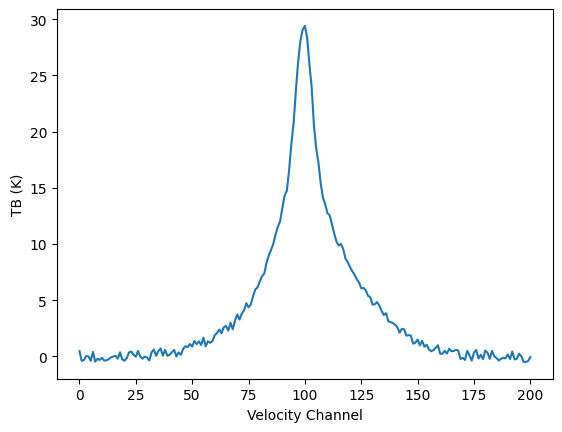

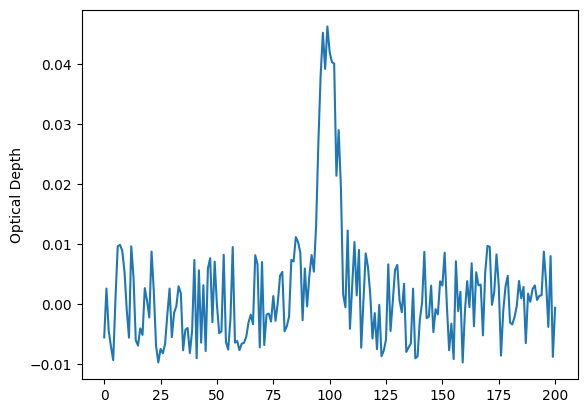

In [11]:
plt.figure
plt.plot(TB[0])
plt.ylabel('TB (K)')
plt.xlabel('Velocity Channel')

plt.figure()
plt.plot(tau[0])
plt.ylabel('Optical Depth')

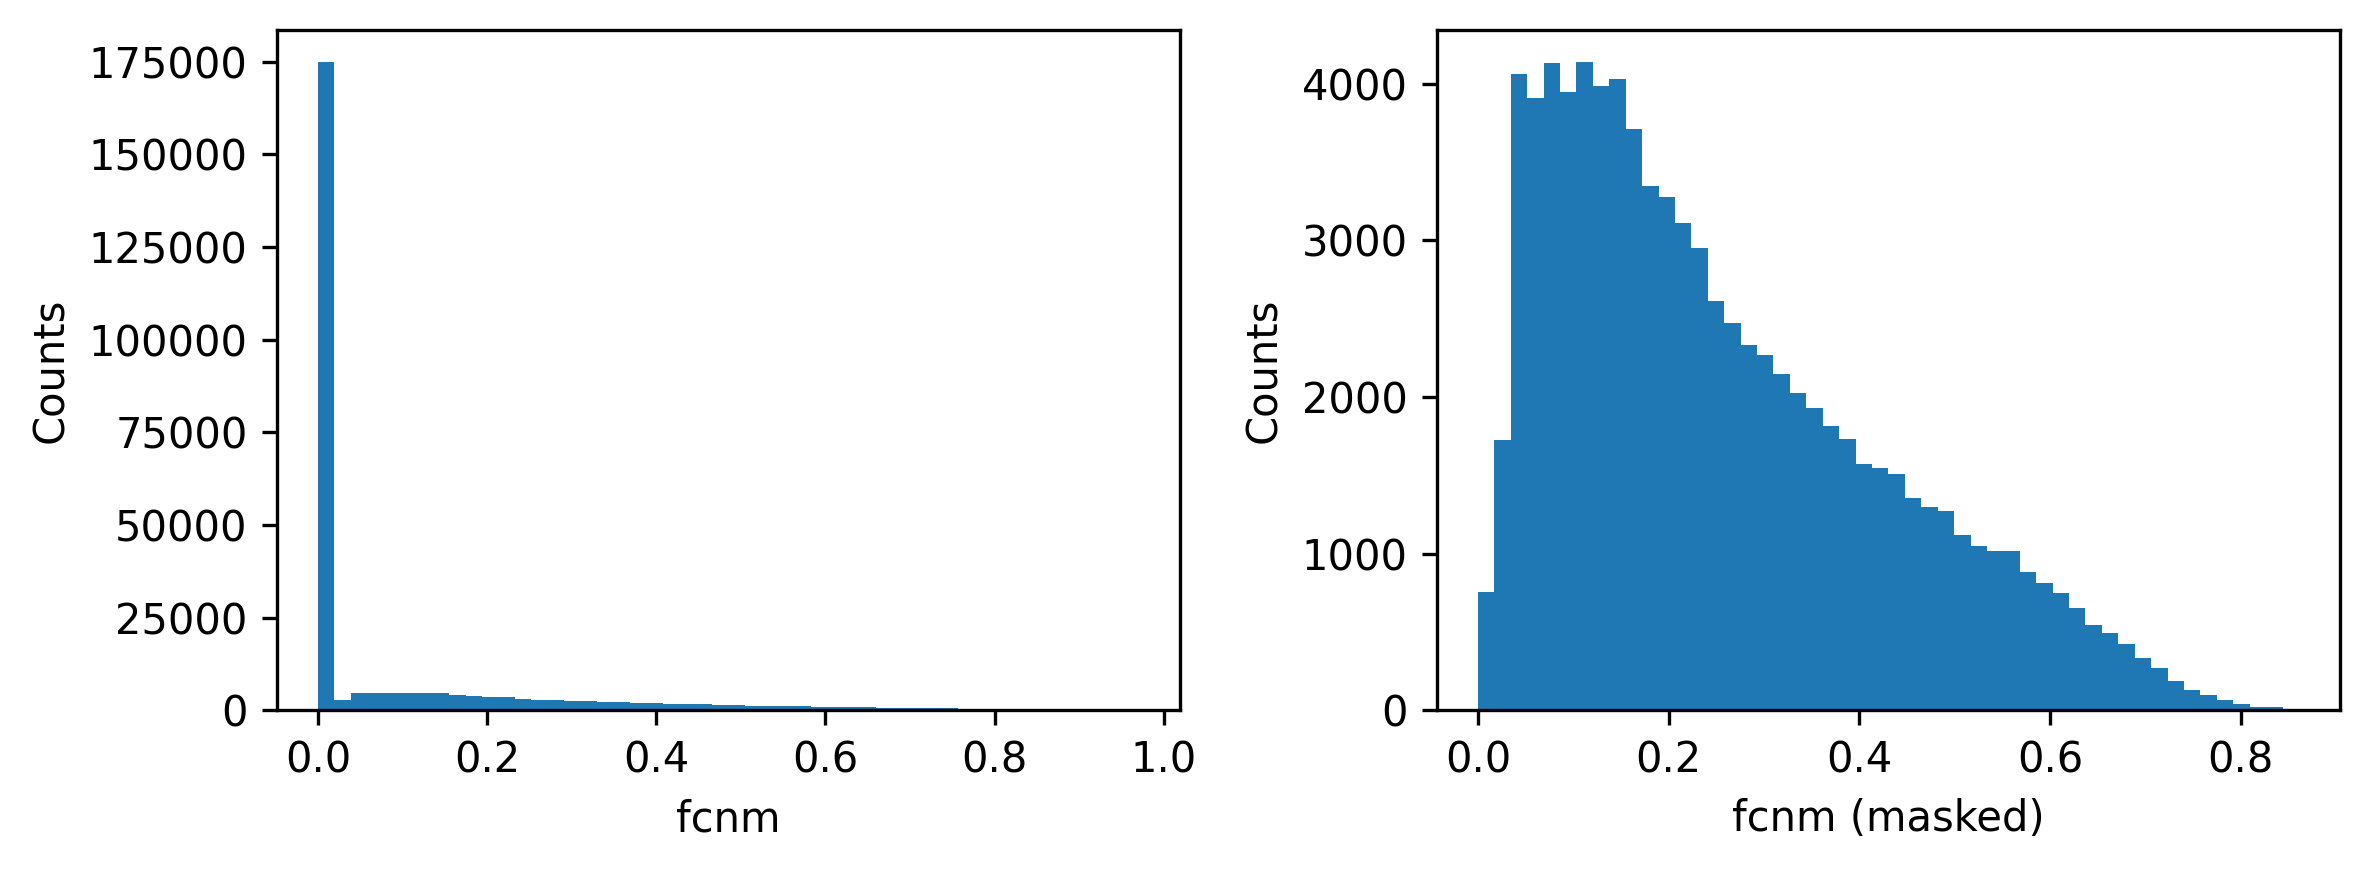

In [12]:
mask = (RHI < 2) & (fcnm > 0)
plt.figure(figsize=(8,3),dpi=300)
plt.subplot(121)
plt.hist(fcnm,bins=50)
plt.xlabel('fcnm')
plt.ylabel('Counts')

plt.subplot(122)
plt.hist(fcnm[mask],bins=50)
plt.xlabel('fcnm (masked)')
plt.ylabel('Counts')

plt.tight_layout()

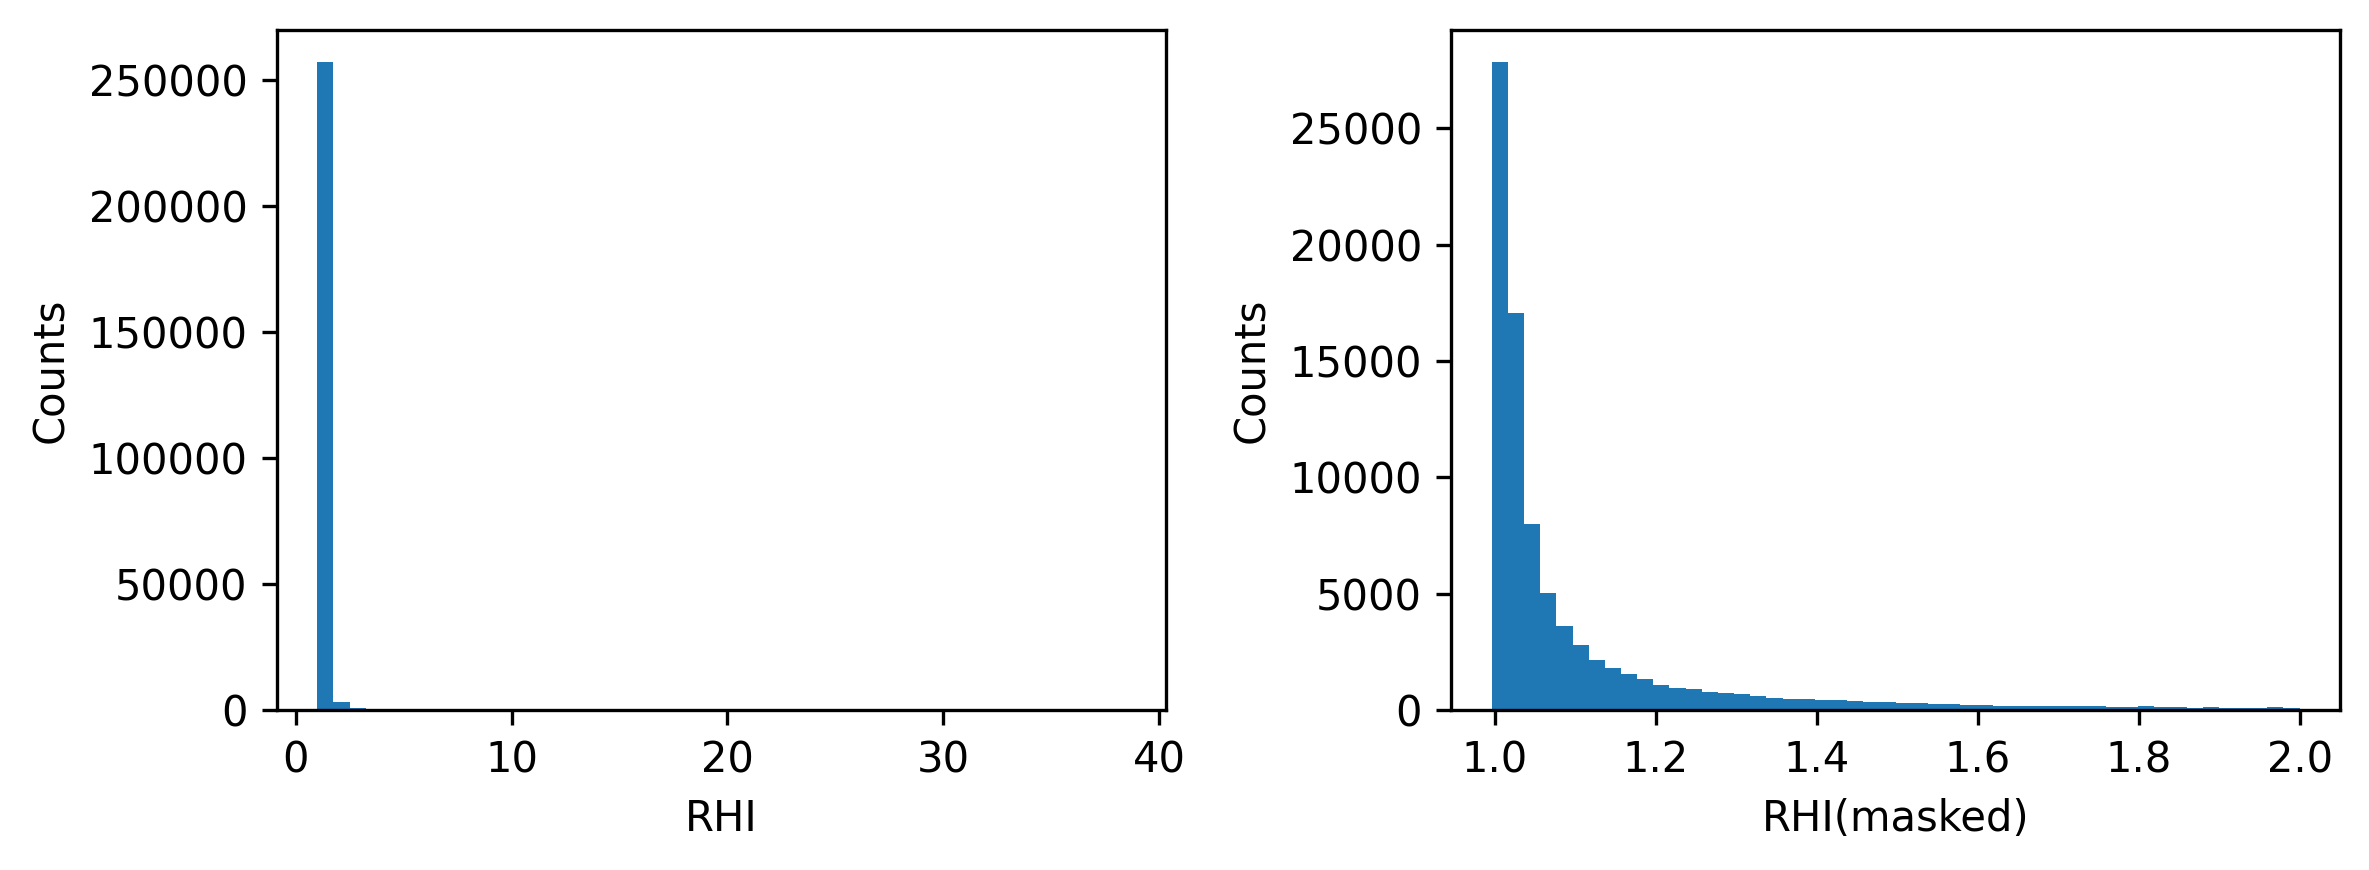

In [13]:
mask = (RHI < 2) & (fcnm > 0) 
plt.figure(figsize=(8,3),dpi=300)
plt.subplot(121)
plt.hist(RHI,bins=50)
plt.xlabel('RHI')
plt.ylabel('Counts')

plt.subplot(122)
plt.hist(RHI[mask],bins=50)
plt.xlabel('RHI(masked)')
plt.ylabel('Counts')
plt.tight_layout()

# evaluate model -- no noise


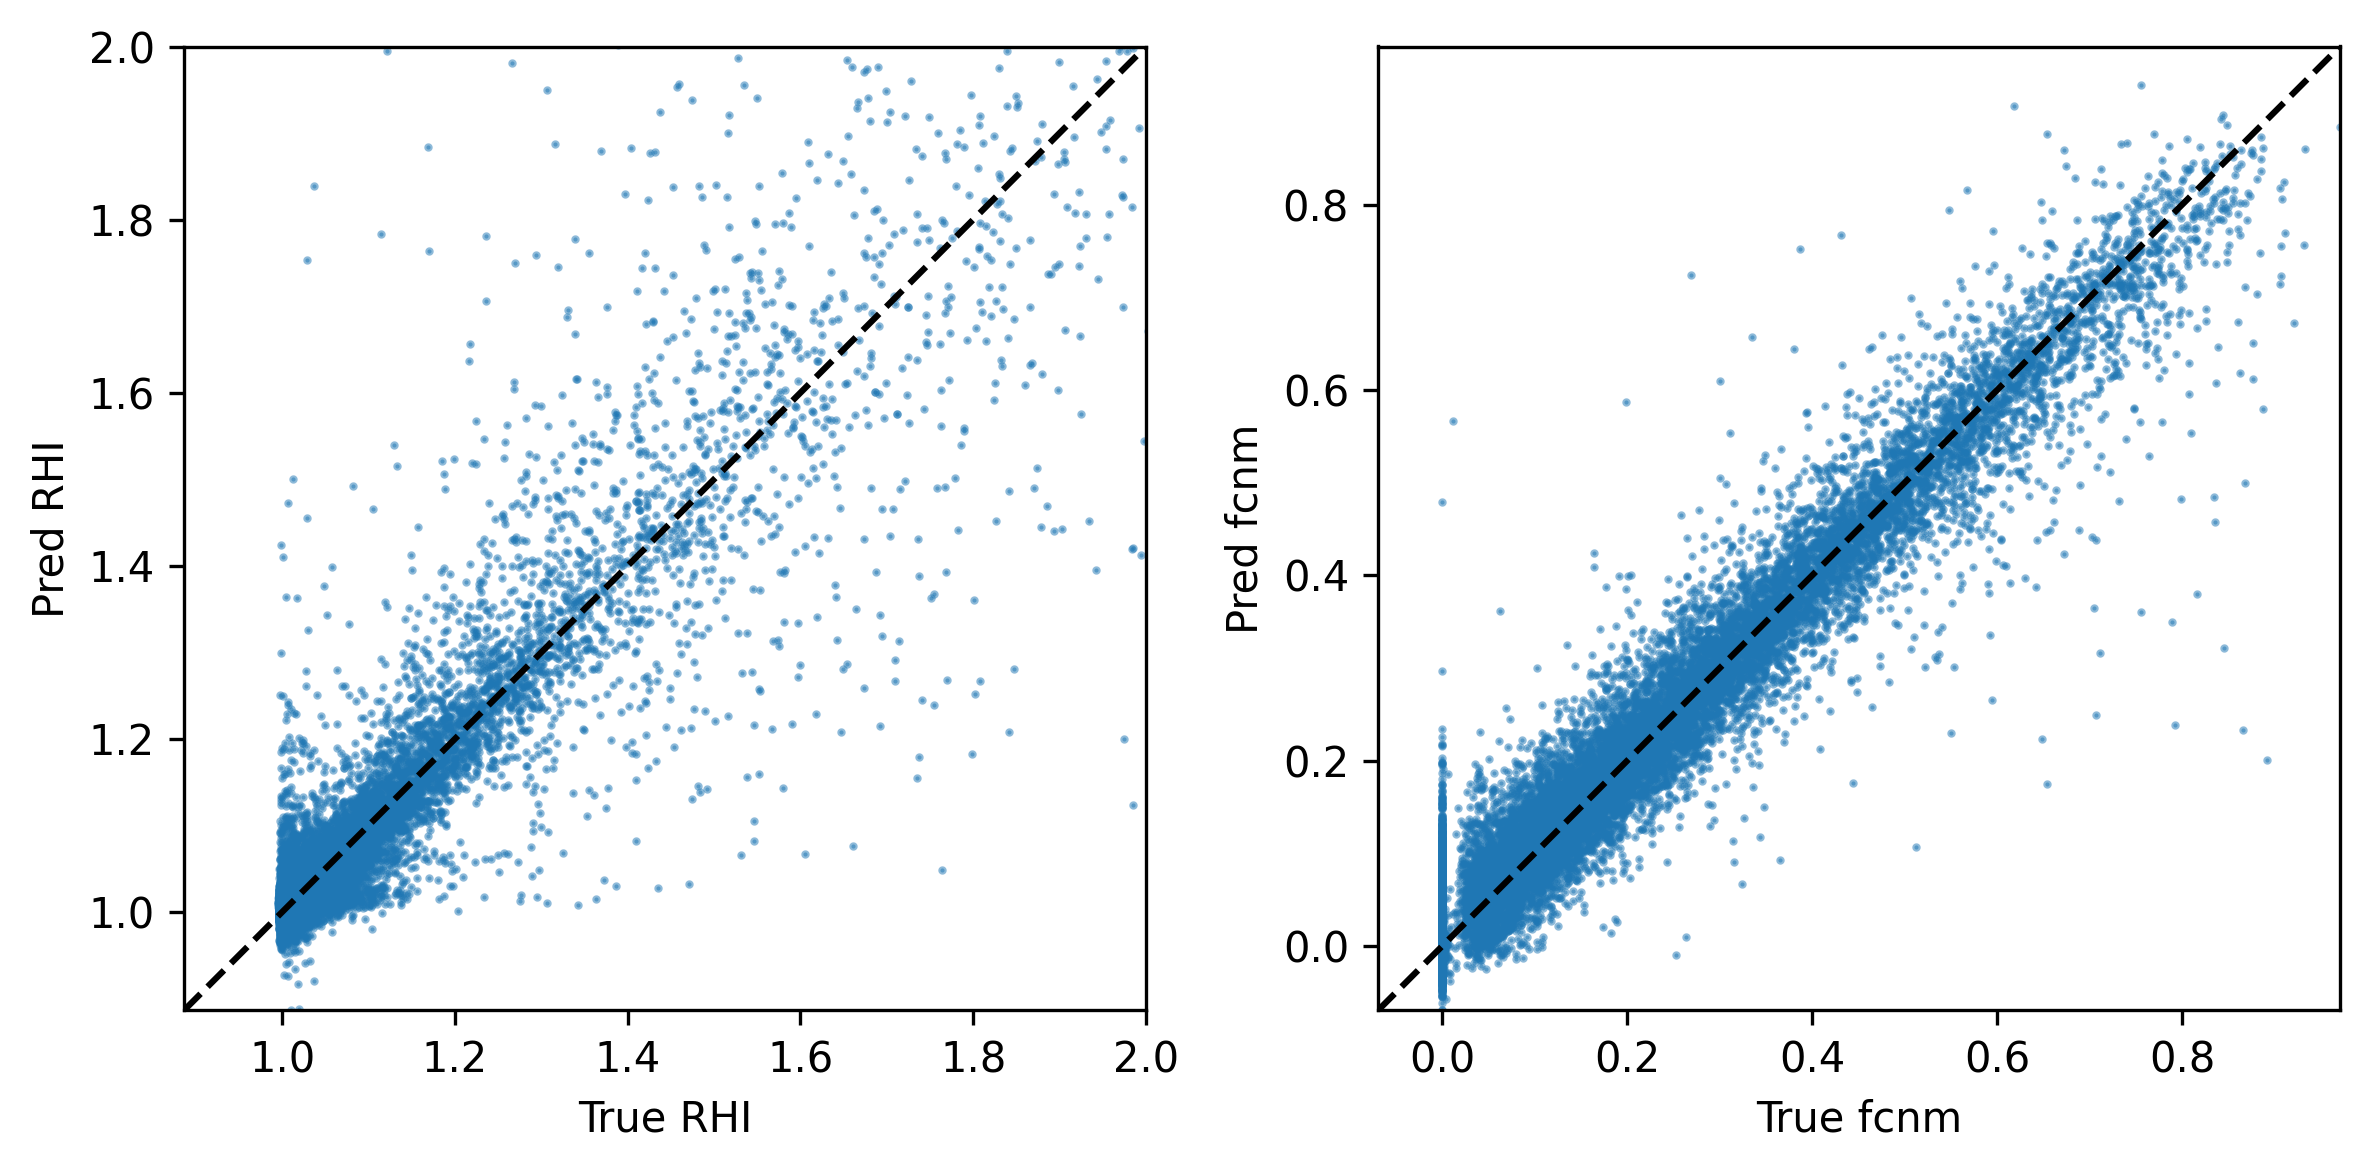

In [20]:
m1=pd.read_csv('test_predictions.csv')
plt.figure(figsize=(8,4),dpi=300)
plt.subplot(121)
plt.scatter(m1['true_rhi'],m1['pred_rhi'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_rhi'].min(), m1['pred_rhi'].min())), float(max(m1['true_rhi'].max(), m1['pred_rhi'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True RHI")
plt.ylabel(f"Pred RHI")
plt.xlim(lo, 2)
plt.ylim(lo, 2)
#
plt.subplot(122)
plt.scatter(m1['true_fcnm'],m1['pred_fcnm'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_fcnm'].min(), m1['pred_fcnm'].min())), float(max(m1['true_fcnm'].max(), m1['pred_fcnm'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True fcnm")
plt.ylabel(f"Pred fcnm")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.tight_layout()

Text(0, 0.5, 'Loss')

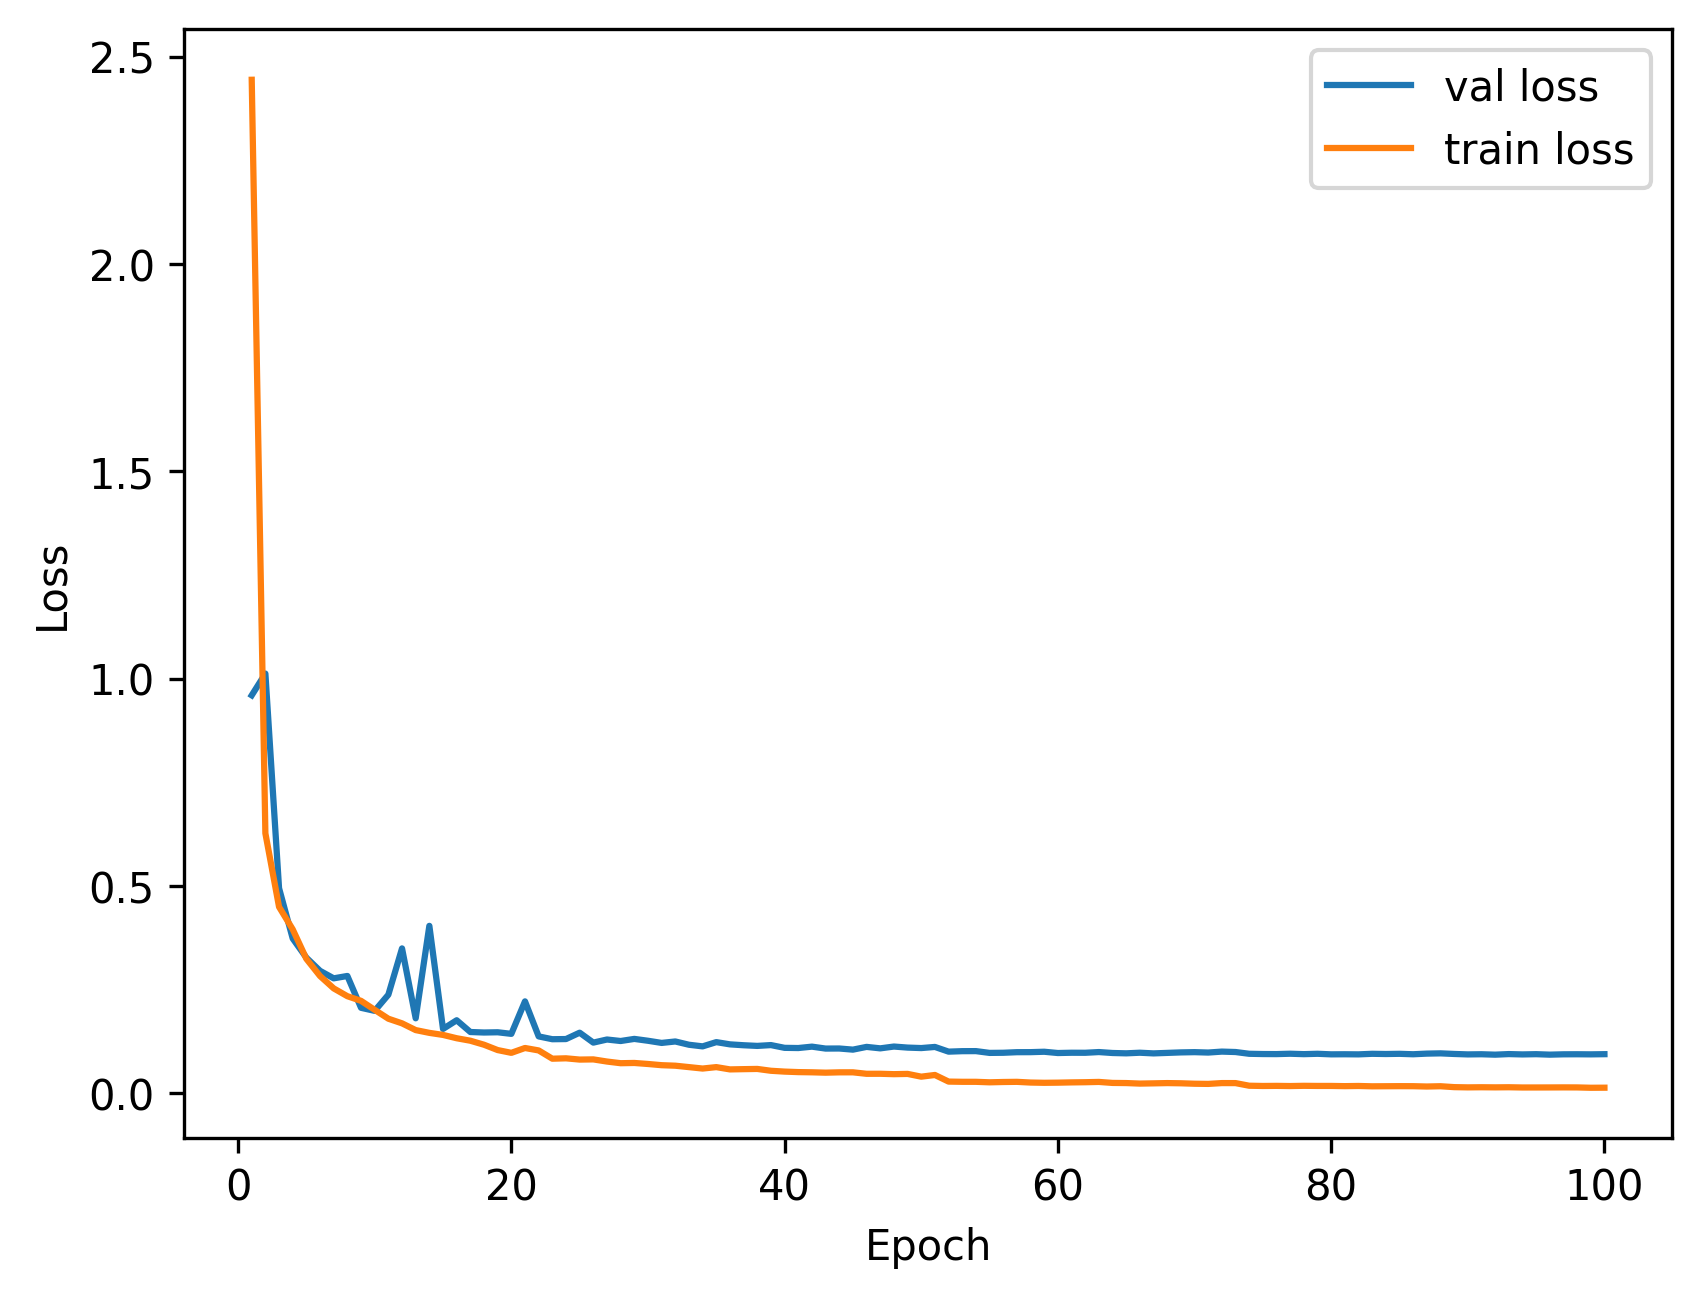

In [21]:
m1_log=pd.read_csv('training_metrics.csv')
plt.figure(dpi=300)
plt.plot(m1_log['epoch'], m1_log['val_loss'],label='val loss')
plt.plot(m1_log['epoch'], m1_log['train_loss'],label='train loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

# evaluate model -- with noise add Tb 0.5, tau 0.01

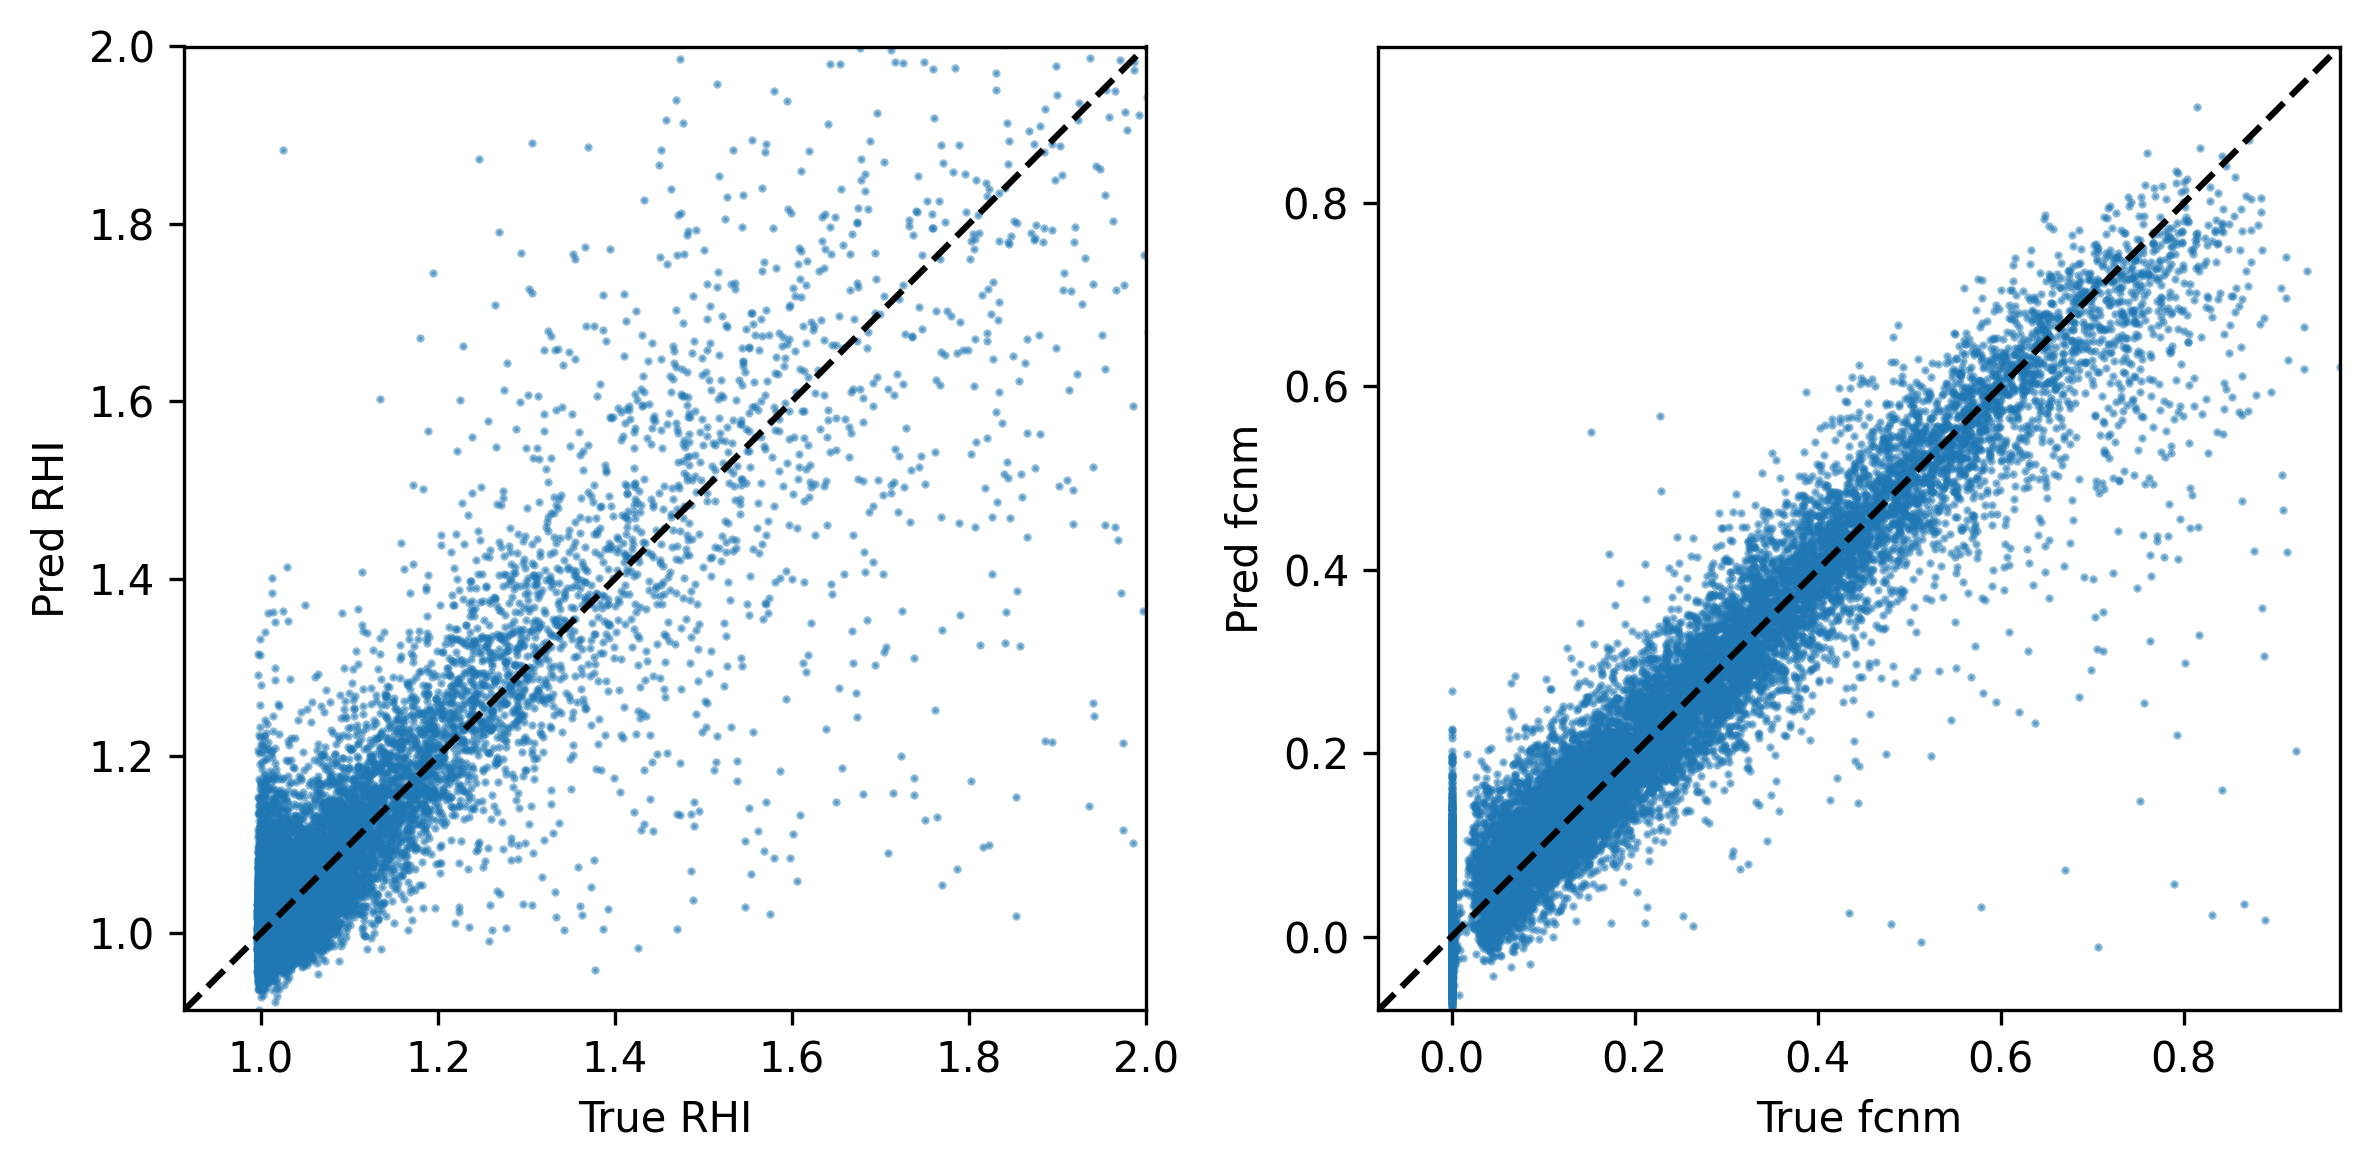

In [17]:
m1=pd.read_csv('noisy_tb/test_predictions.csv')
plt.figure(figsize=(8,4),dpi=300)
plt.subplot(121)
plt.scatter(m1['true_rhi'],m1['pred_rhi'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_rhi'].min(), m1['pred_rhi'].min())), float(max(m1['true_rhi'].max(), m1['pred_rhi'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True RHI")
plt.ylabel(f"Pred RHI")
plt.xlim(lo, 2)
plt.ylim(lo, 2)
#
plt.subplot(122)
plt.scatter(m1['true_fcnm'],m1['pred_fcnm'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_fcnm'].min(), m1['pred_fcnm'].min())), float(max(m1['true_fcnm'].max(), m1['pred_fcnm'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True fcnm")
plt.ylabel(f"Pred fcnm")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.tight_layout()

Text(0, 0.5, 'Loss')

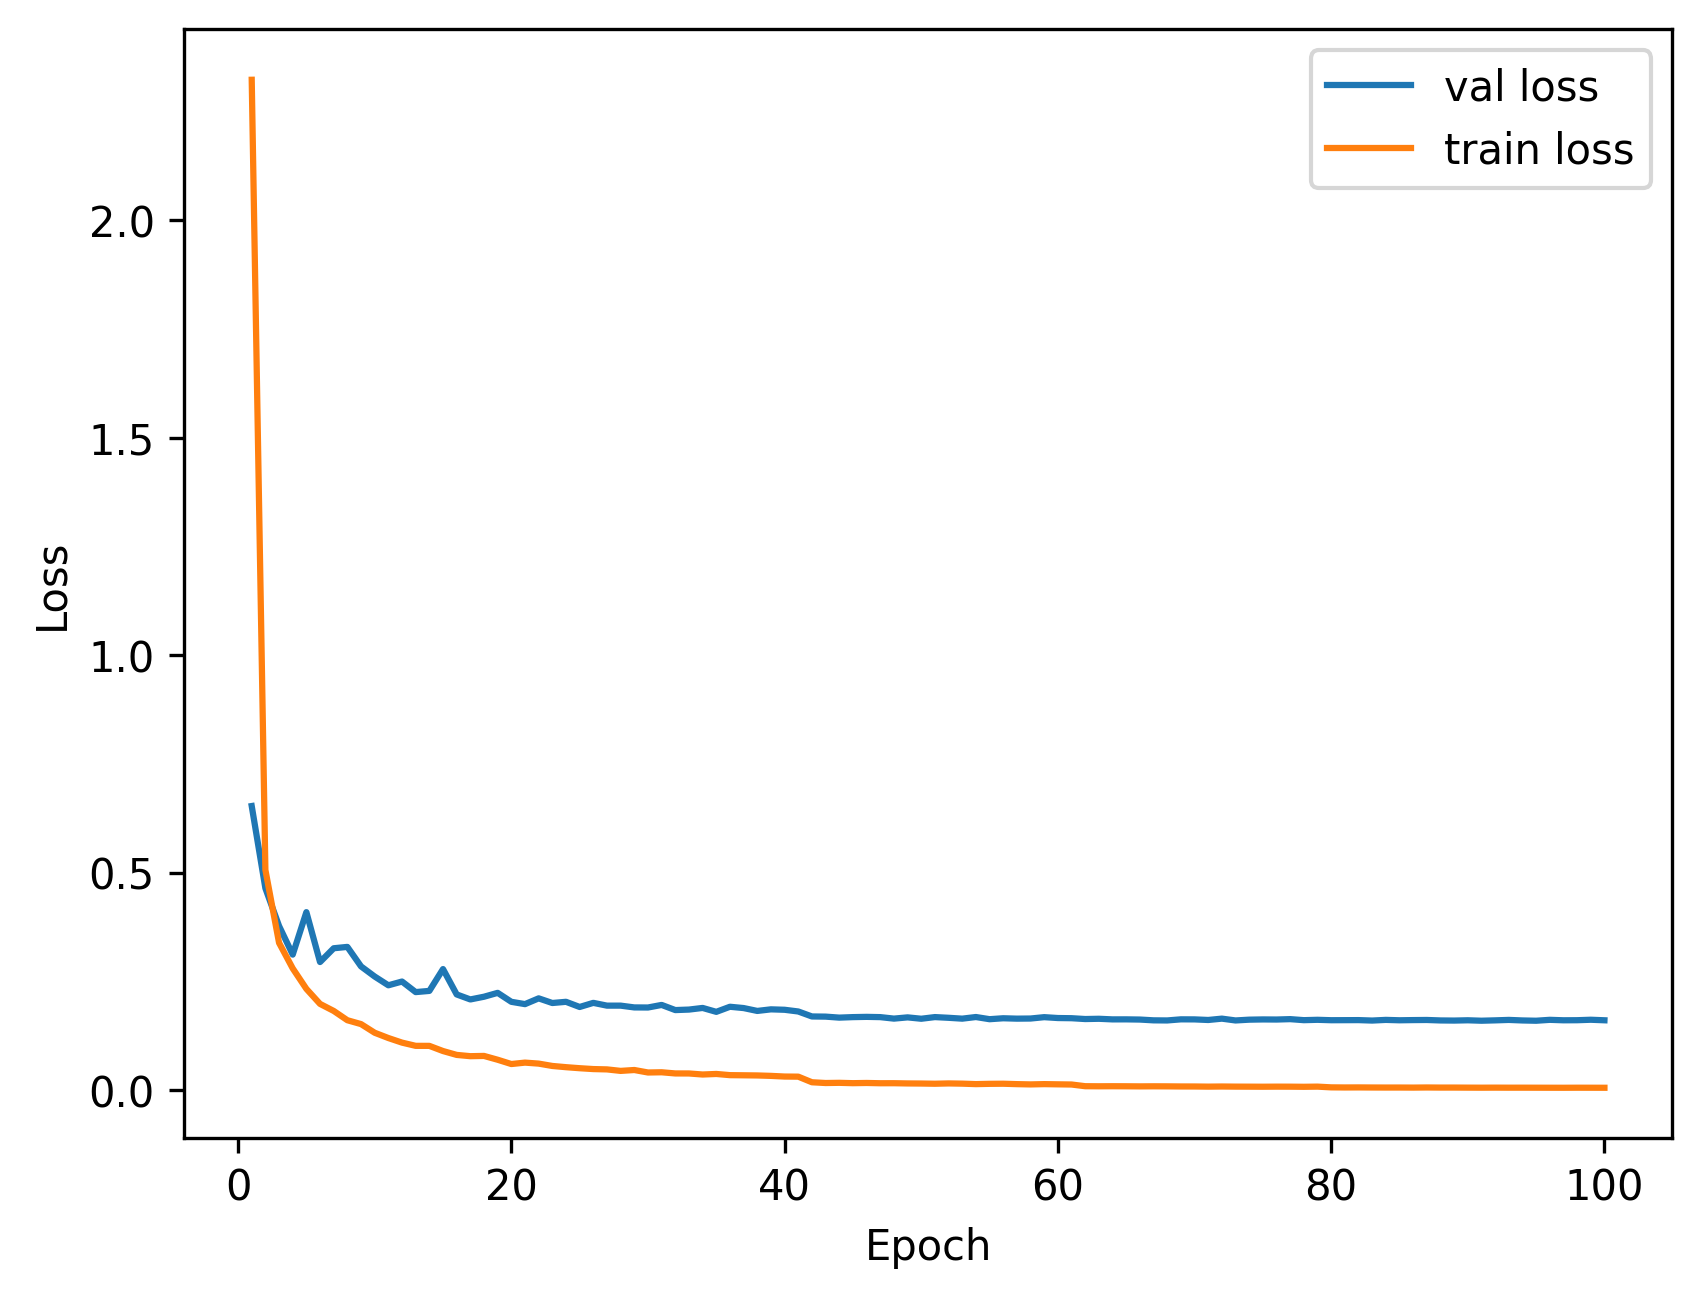

In [19]:
m1_log=pd.read_csv('noisy_tb/training_metrics.csv')
plt.figure(dpi=300)
plt.plot(m1_log['epoch'], m1_log['val_loss'],label='val loss')
plt.plot(m1_log['epoch'], m1_log['train_loss'],label='train loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

# no noise diff layers

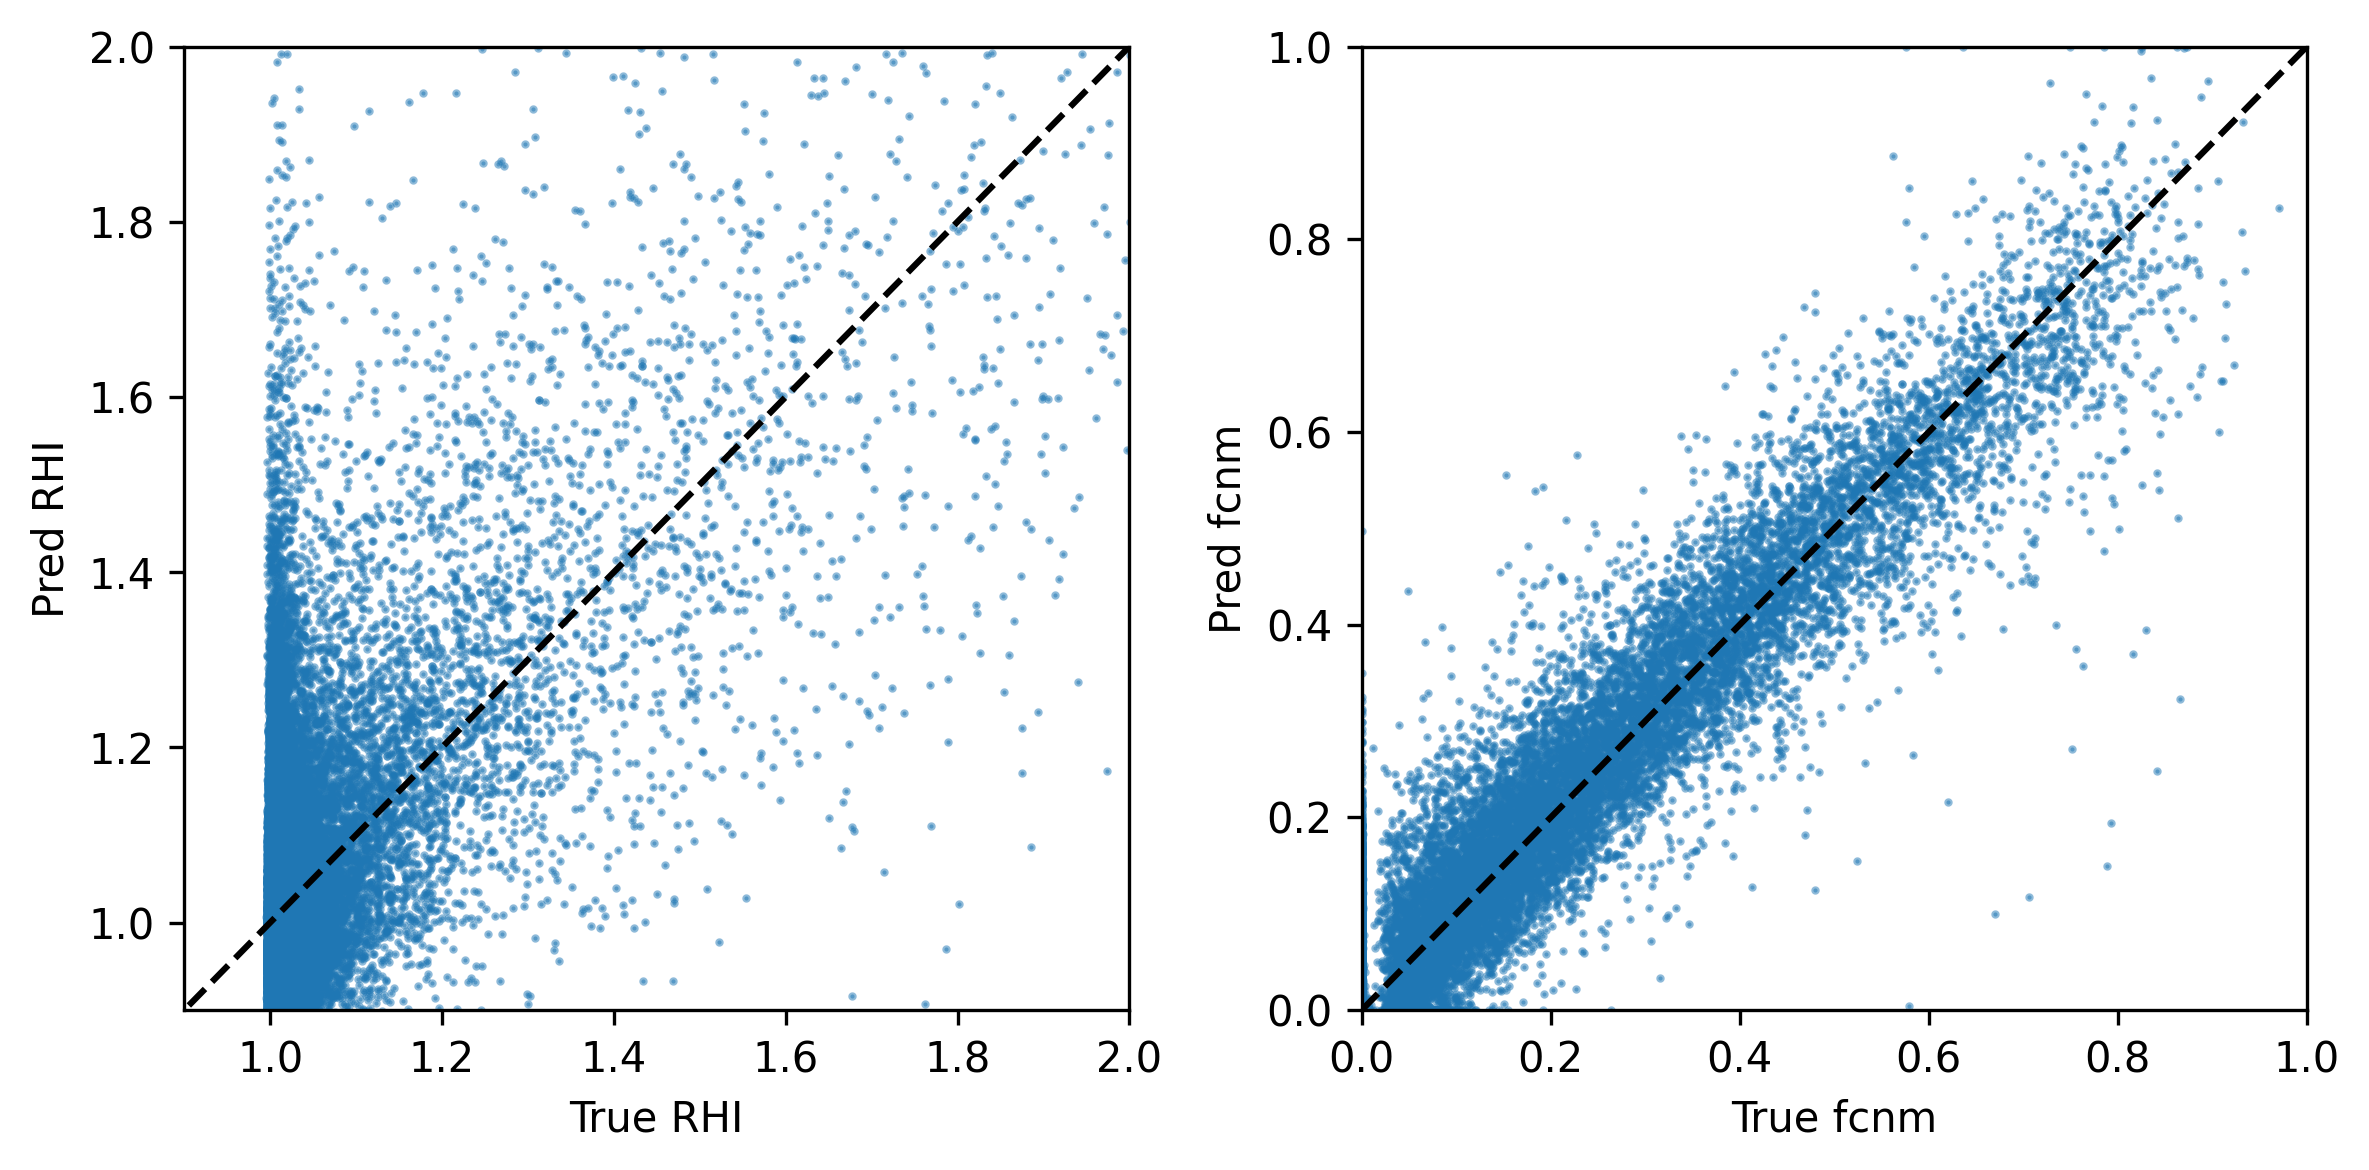

In [4]:
m1=pd.read_csv('layer_sweep_full_layers2/test_predictions_layers2.csv')
plt.figure(figsize=(8,4),dpi=300)
plt.subplot(121)
plt.scatter(m1['true_rhi'],m1['pred_rhi'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_rhi'].min(), m1['pred_rhi'].min())), float(max(m1['true_rhi'].max(), m1['pred_rhi'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True RHI")
plt.ylabel(f"Pred RHI")
plt.xlim(0.9, 2)
plt.ylim(0.9, 2)
#
plt.subplot(122)
plt.scatter(m1['true_fcnm'],m1['pred_fcnm'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_fcnm'].min(), m1['pred_fcnm'].min())), float(max(m1['true_fcnm'].max(), m1['pred_fcnm'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True fcnm")
plt.ylabel(f"Pred fcnm")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.tight_layout()

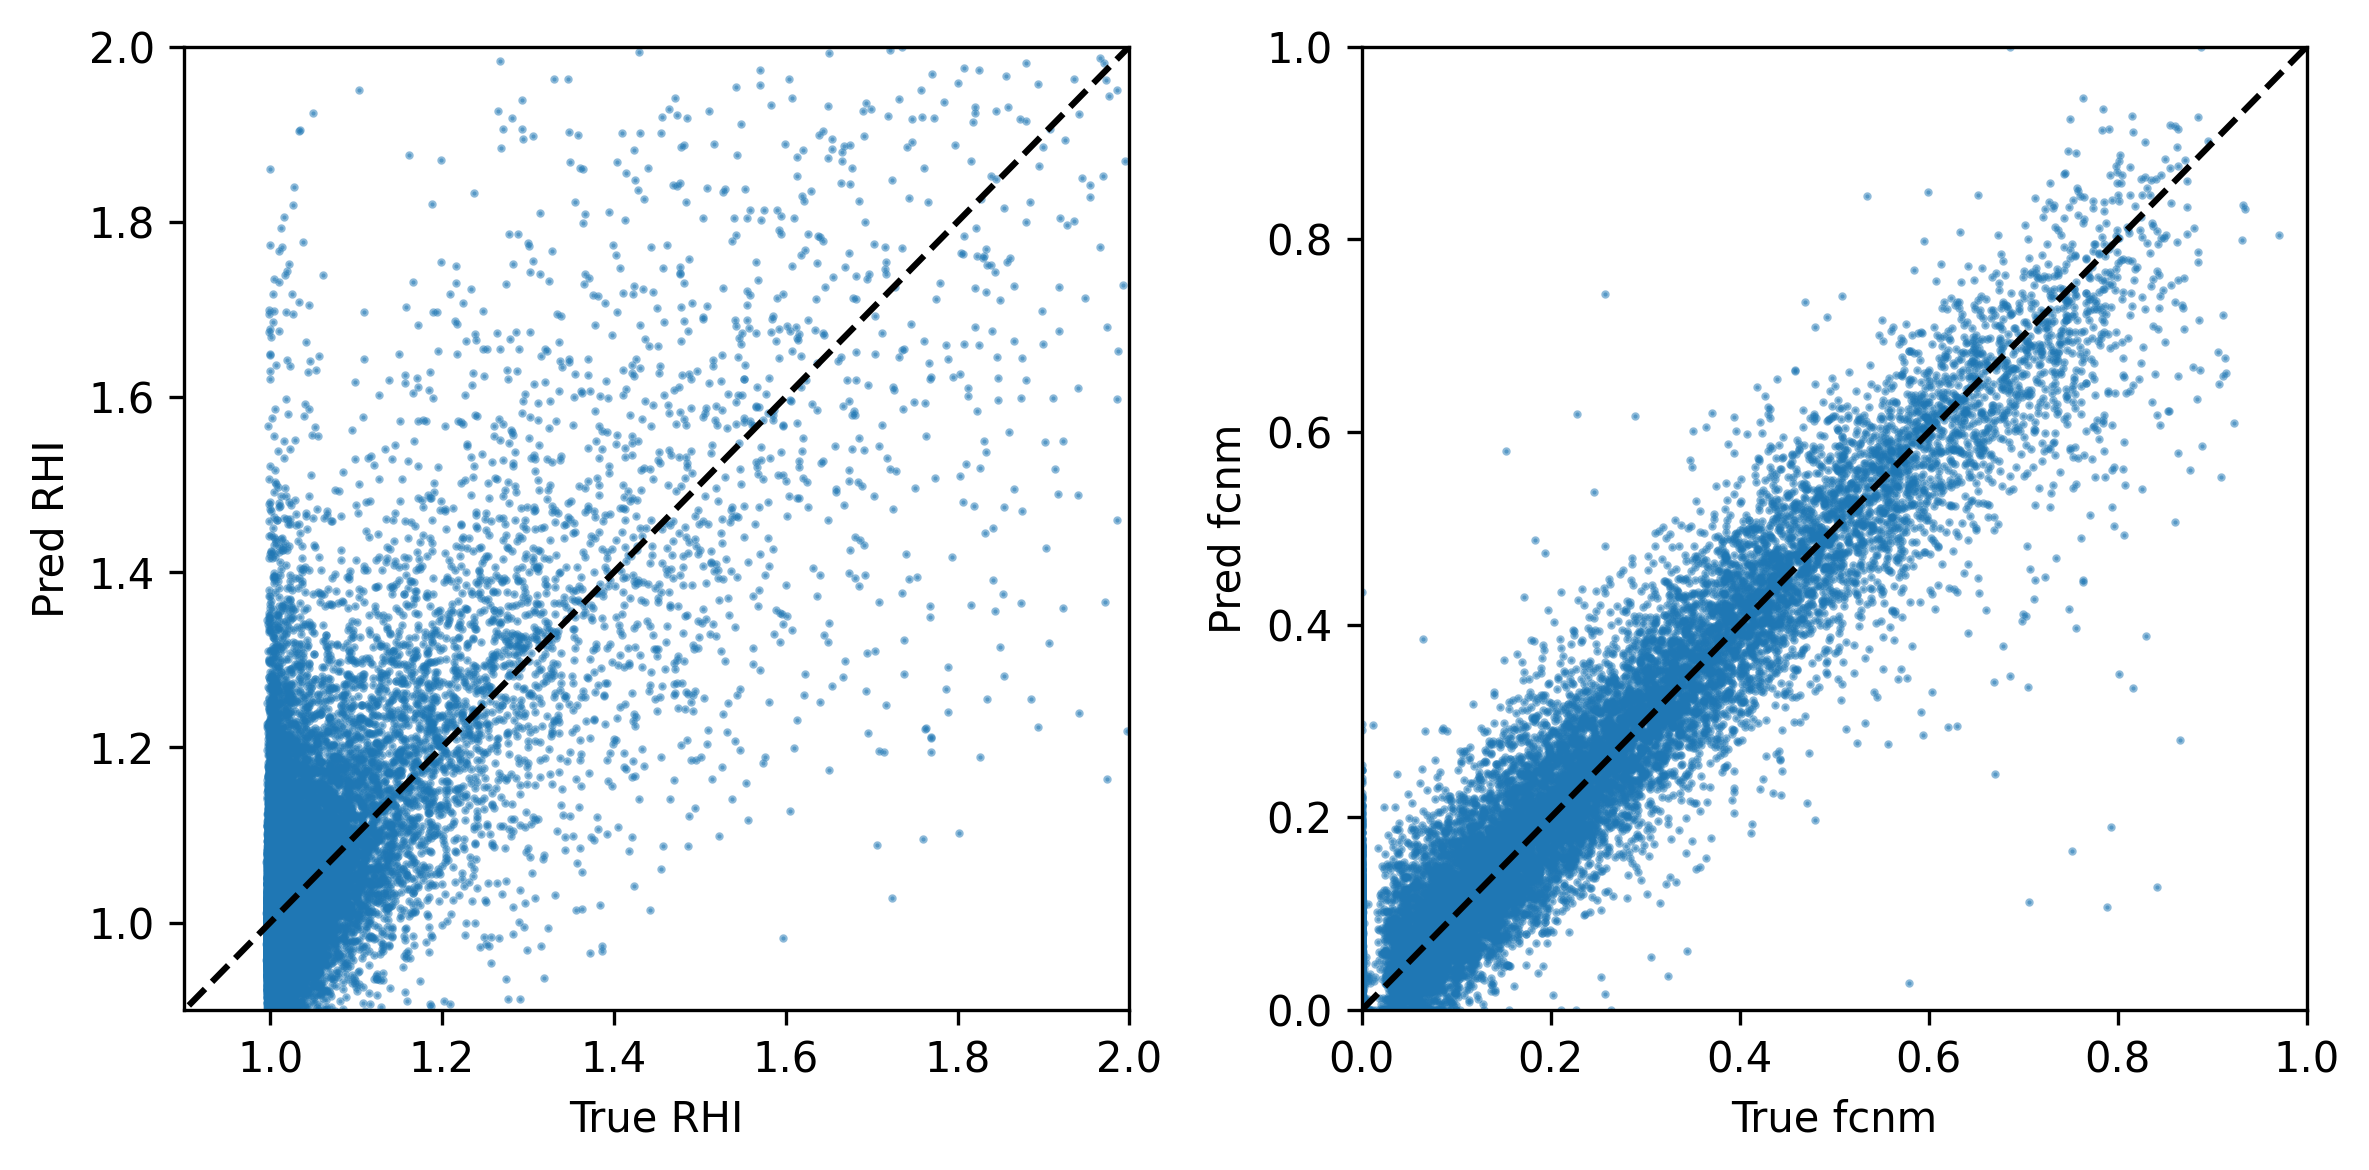

In [5]:
m1=pd.read_csv('layer_sweep_full_layers3/test_predictions_layers3.csv')
plt.figure(figsize=(8,4),dpi=300)
plt.subplot(121)
plt.scatter(m1['true_rhi'],m1['pred_rhi'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_rhi'].min(), m1['pred_rhi'].min())), float(max(m1['true_rhi'].max(), m1['pred_rhi'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True RHI")
plt.ylabel(f"Pred RHI")
plt.xlim(0.9, 2)
plt.ylim(0.9, 2)
#
plt.subplot(122)
plt.scatter(m1['true_fcnm'],m1['pred_fcnm'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_fcnm'].min(), m1['pred_fcnm'].min())), float(max(m1['true_fcnm'].max(), m1['pred_fcnm'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True fcnm")
plt.ylabel(f"Pred fcnm")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.tight_layout()

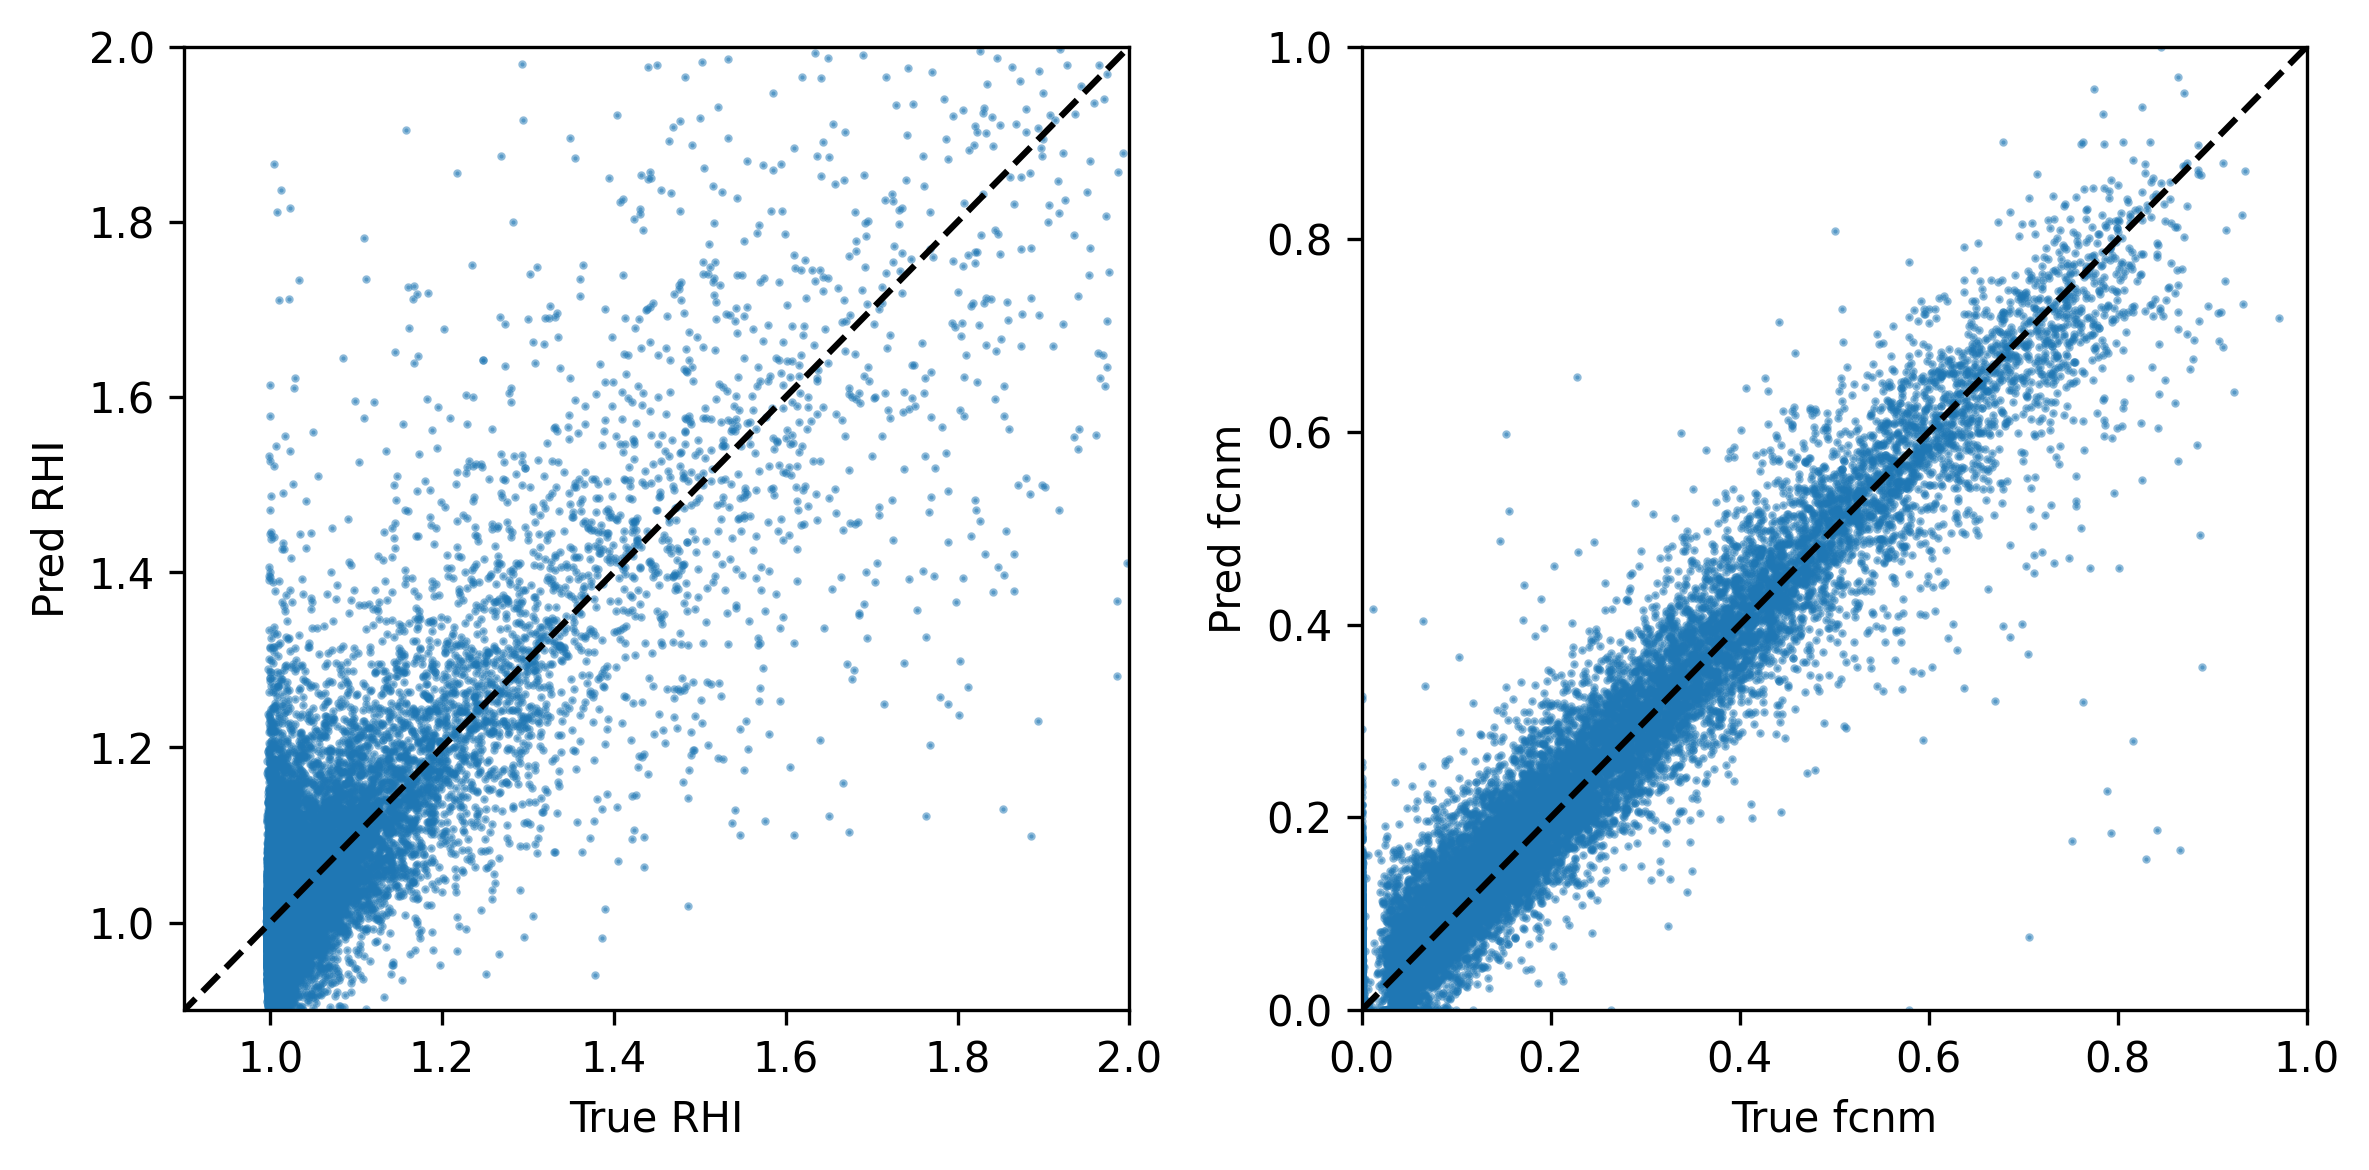

In [6]:
m1=pd.read_csv('layer_sweep_full_layers4/test_predictions_layers4.csv')
plt.figure(figsize=(8,4),dpi=300)
plt.subplot(121)
plt.scatter(m1['true_rhi'],m1['pred_rhi'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_rhi'].min(), m1['pred_rhi'].min())), float(max(m1['true_rhi'].max(), m1['pred_rhi'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True RHI")
plt.ylabel(f"Pred RHI")
plt.xlim(0.9, 2)
plt.ylim(0.9, 2)
#
plt.subplot(122)
plt.scatter(m1['true_fcnm'],m1['pred_fcnm'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_fcnm'].min(), m1['pred_fcnm'].min())), float(max(m1['true_fcnm'].max(), m1['pred_fcnm'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True fcnm")
plt.ylabel(f"Pred fcnm")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.tight_layout()

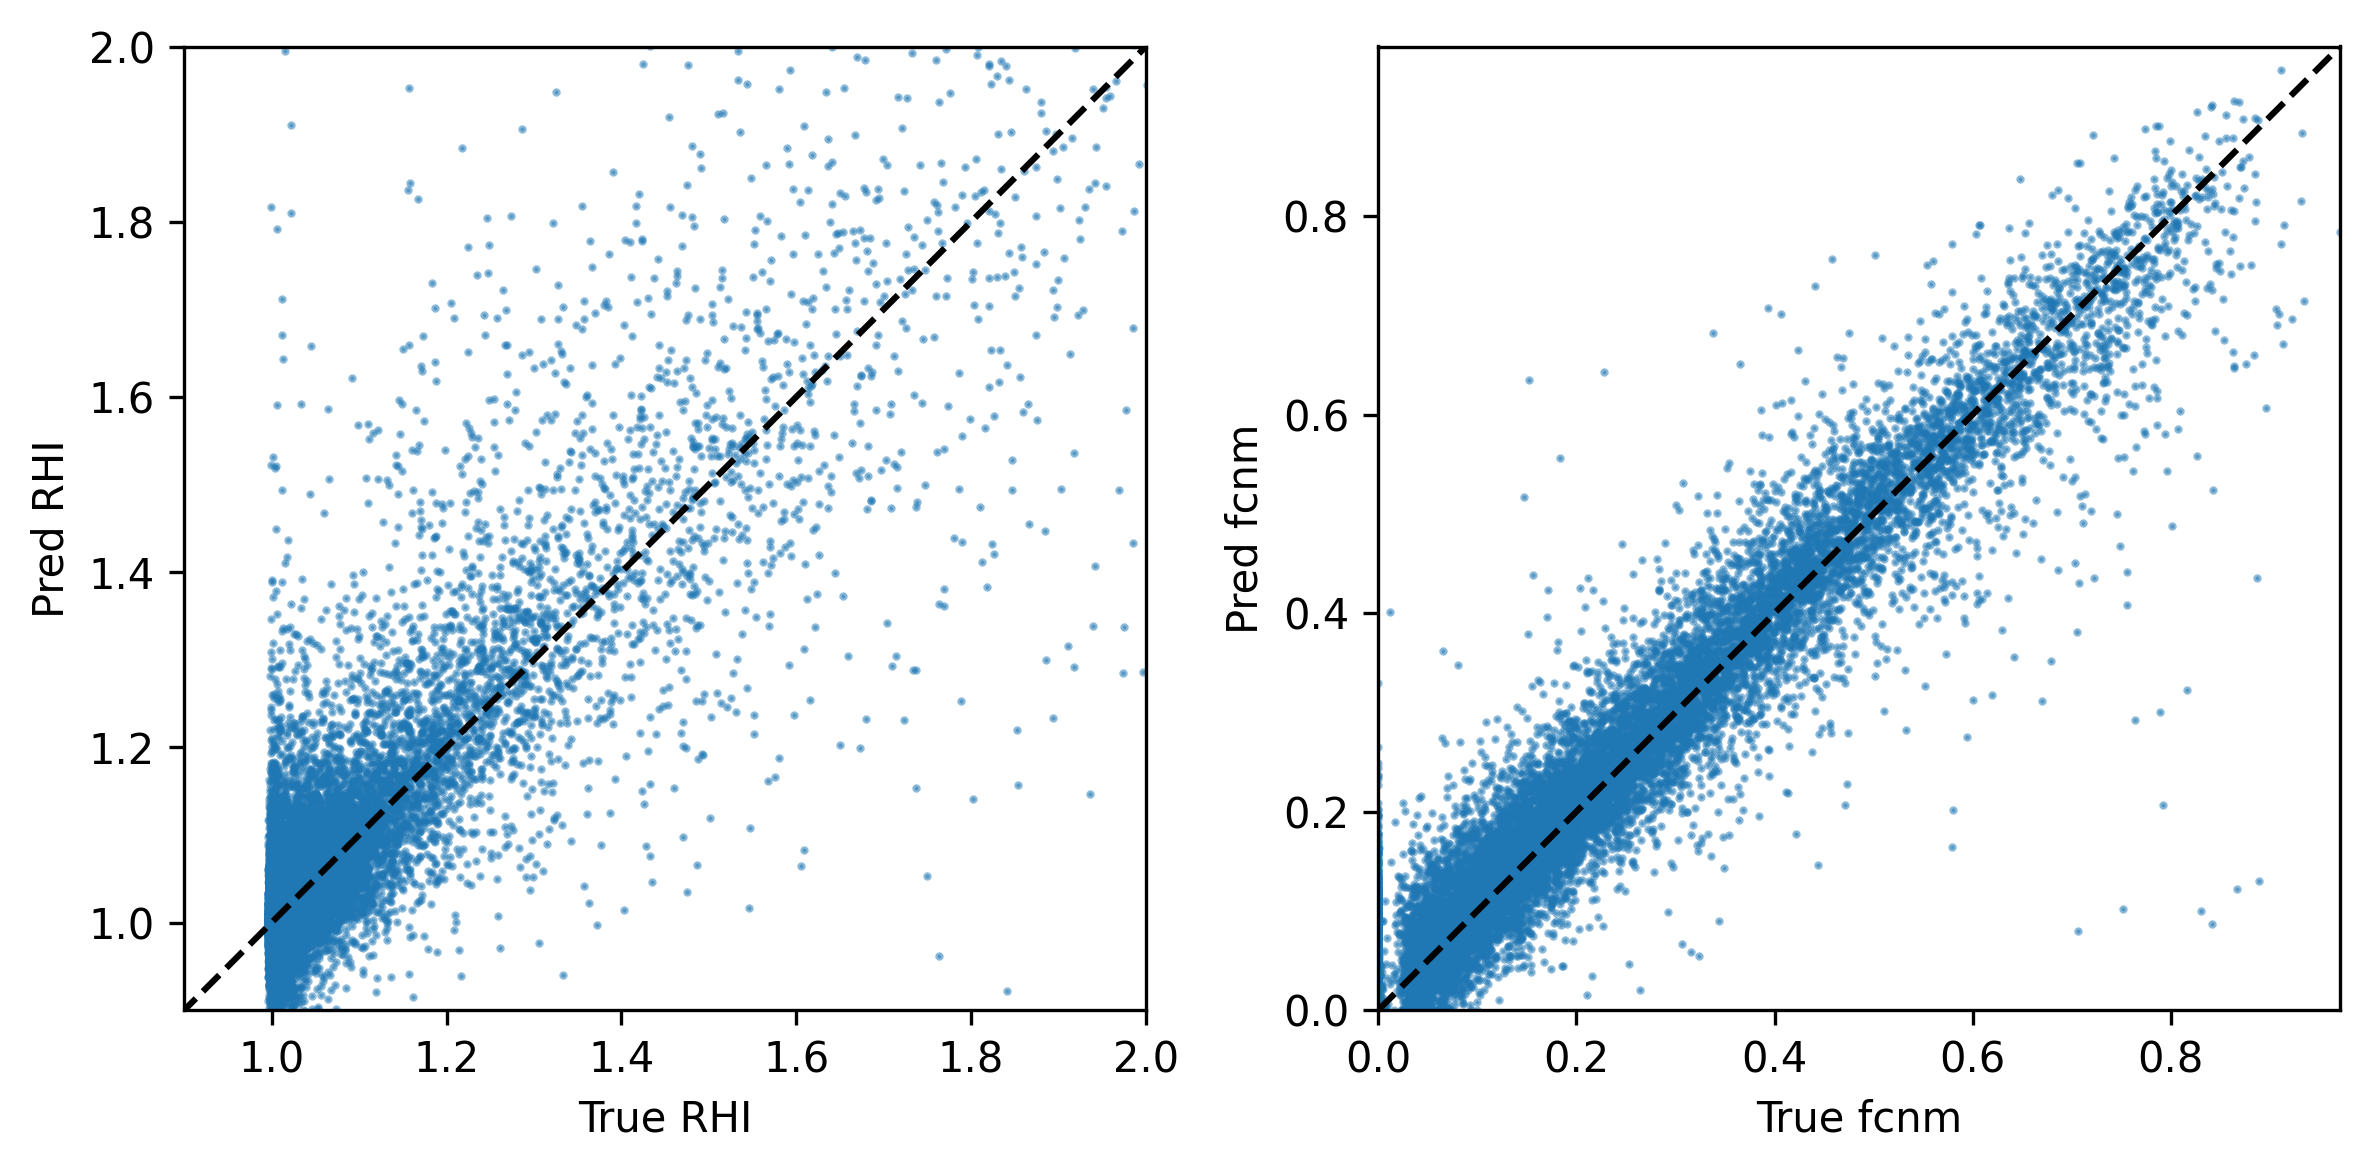

In [2]:
m1=pd.read_csv('layer_sweep_full_layers5/test_predictions_layers5.csv')
plt.figure(figsize=(8,4),dpi=300)
plt.subplot(121)
plt.scatter(m1['true_rhi'],m1['pred_rhi'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_rhi'].min(), m1['pred_rhi'].min())), float(max(m1['true_rhi'].max(), m1['pred_rhi'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True RHI")
plt.ylabel(f"Pred RHI")
plt.xlim(0.9, 2)
plt.ylim(0.9, 2)
#
plt.subplot(122)
plt.scatter(m1['true_fcnm'],m1['pred_fcnm'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_fcnm'].min(), m1['pred_fcnm'].min())), float(max(m1['true_fcnm'].max(), m1['pred_fcnm'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True fcnm")
plt.ylabel(f"Pred fcnm")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.tight_layout()

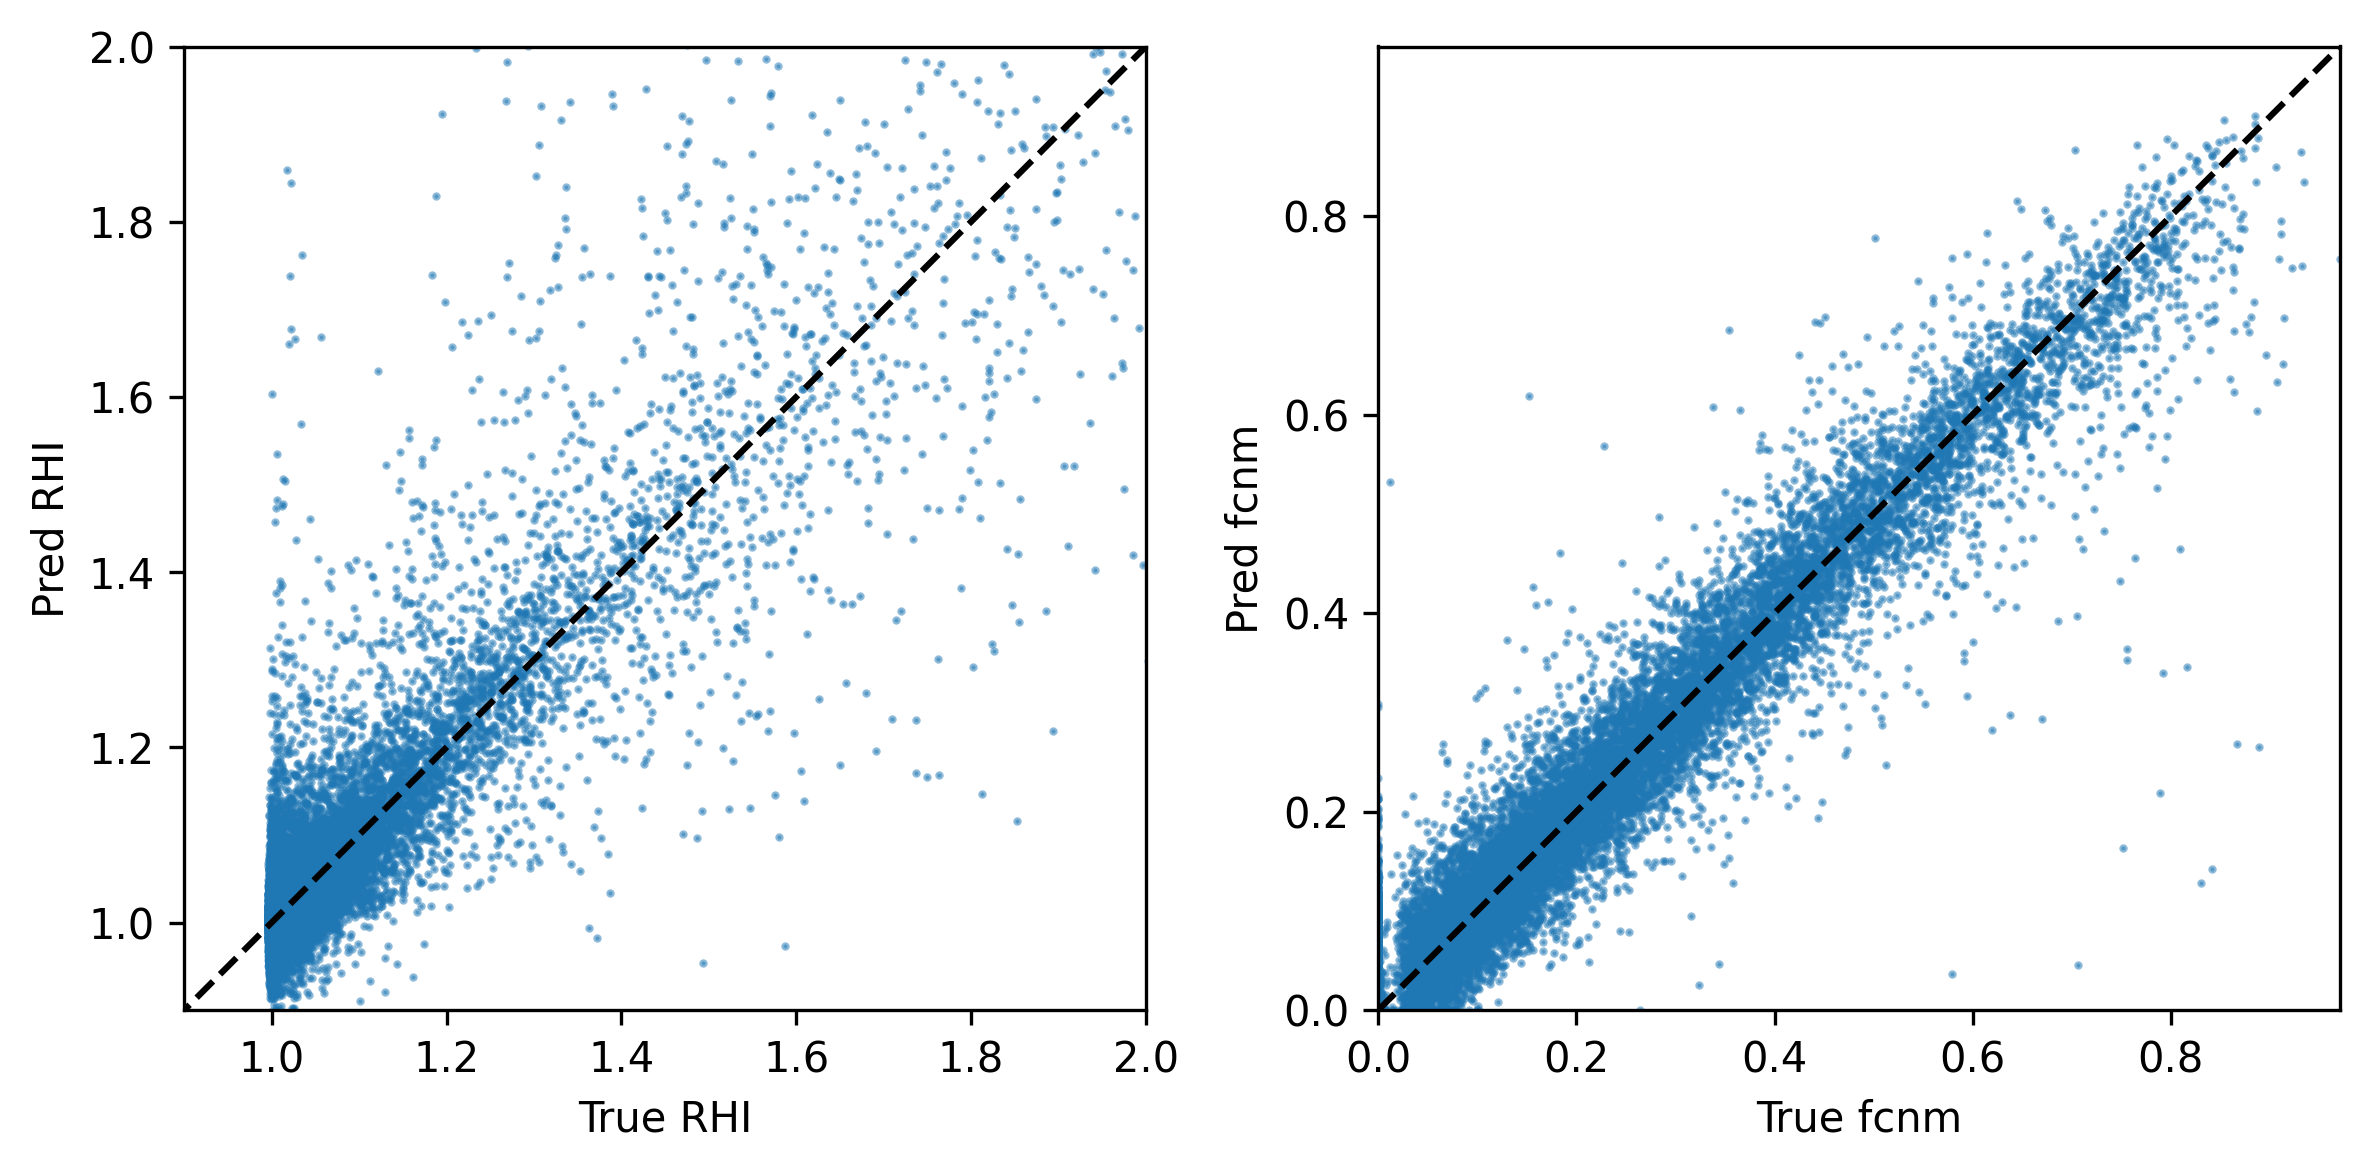

In [3]:
m1=pd.read_csv('layer_sweep_full_layers6/test_predictions_layers6.csv')
plt.figure(figsize=(8,4),dpi=300)
plt.subplot(121)
plt.scatter(m1['true_rhi'],m1['pred_rhi'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_rhi'].min(), m1['pred_rhi'].min())), float(max(m1['true_rhi'].max(), m1['pred_rhi'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True RHI")
plt.ylabel(f"Pred RHI")
plt.xlim(0.9, 2)
plt.ylim(0.9, 2)
#
plt.subplot(122)
plt.scatter(m1['true_fcnm'],m1['pred_fcnm'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_fcnm'].min(), m1['pred_fcnm'].min())), float(max(m1['true_fcnm'].max(), m1['pred_fcnm'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True fcnm")
plt.ylabel(f"Pred fcnm")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.tight_layout()

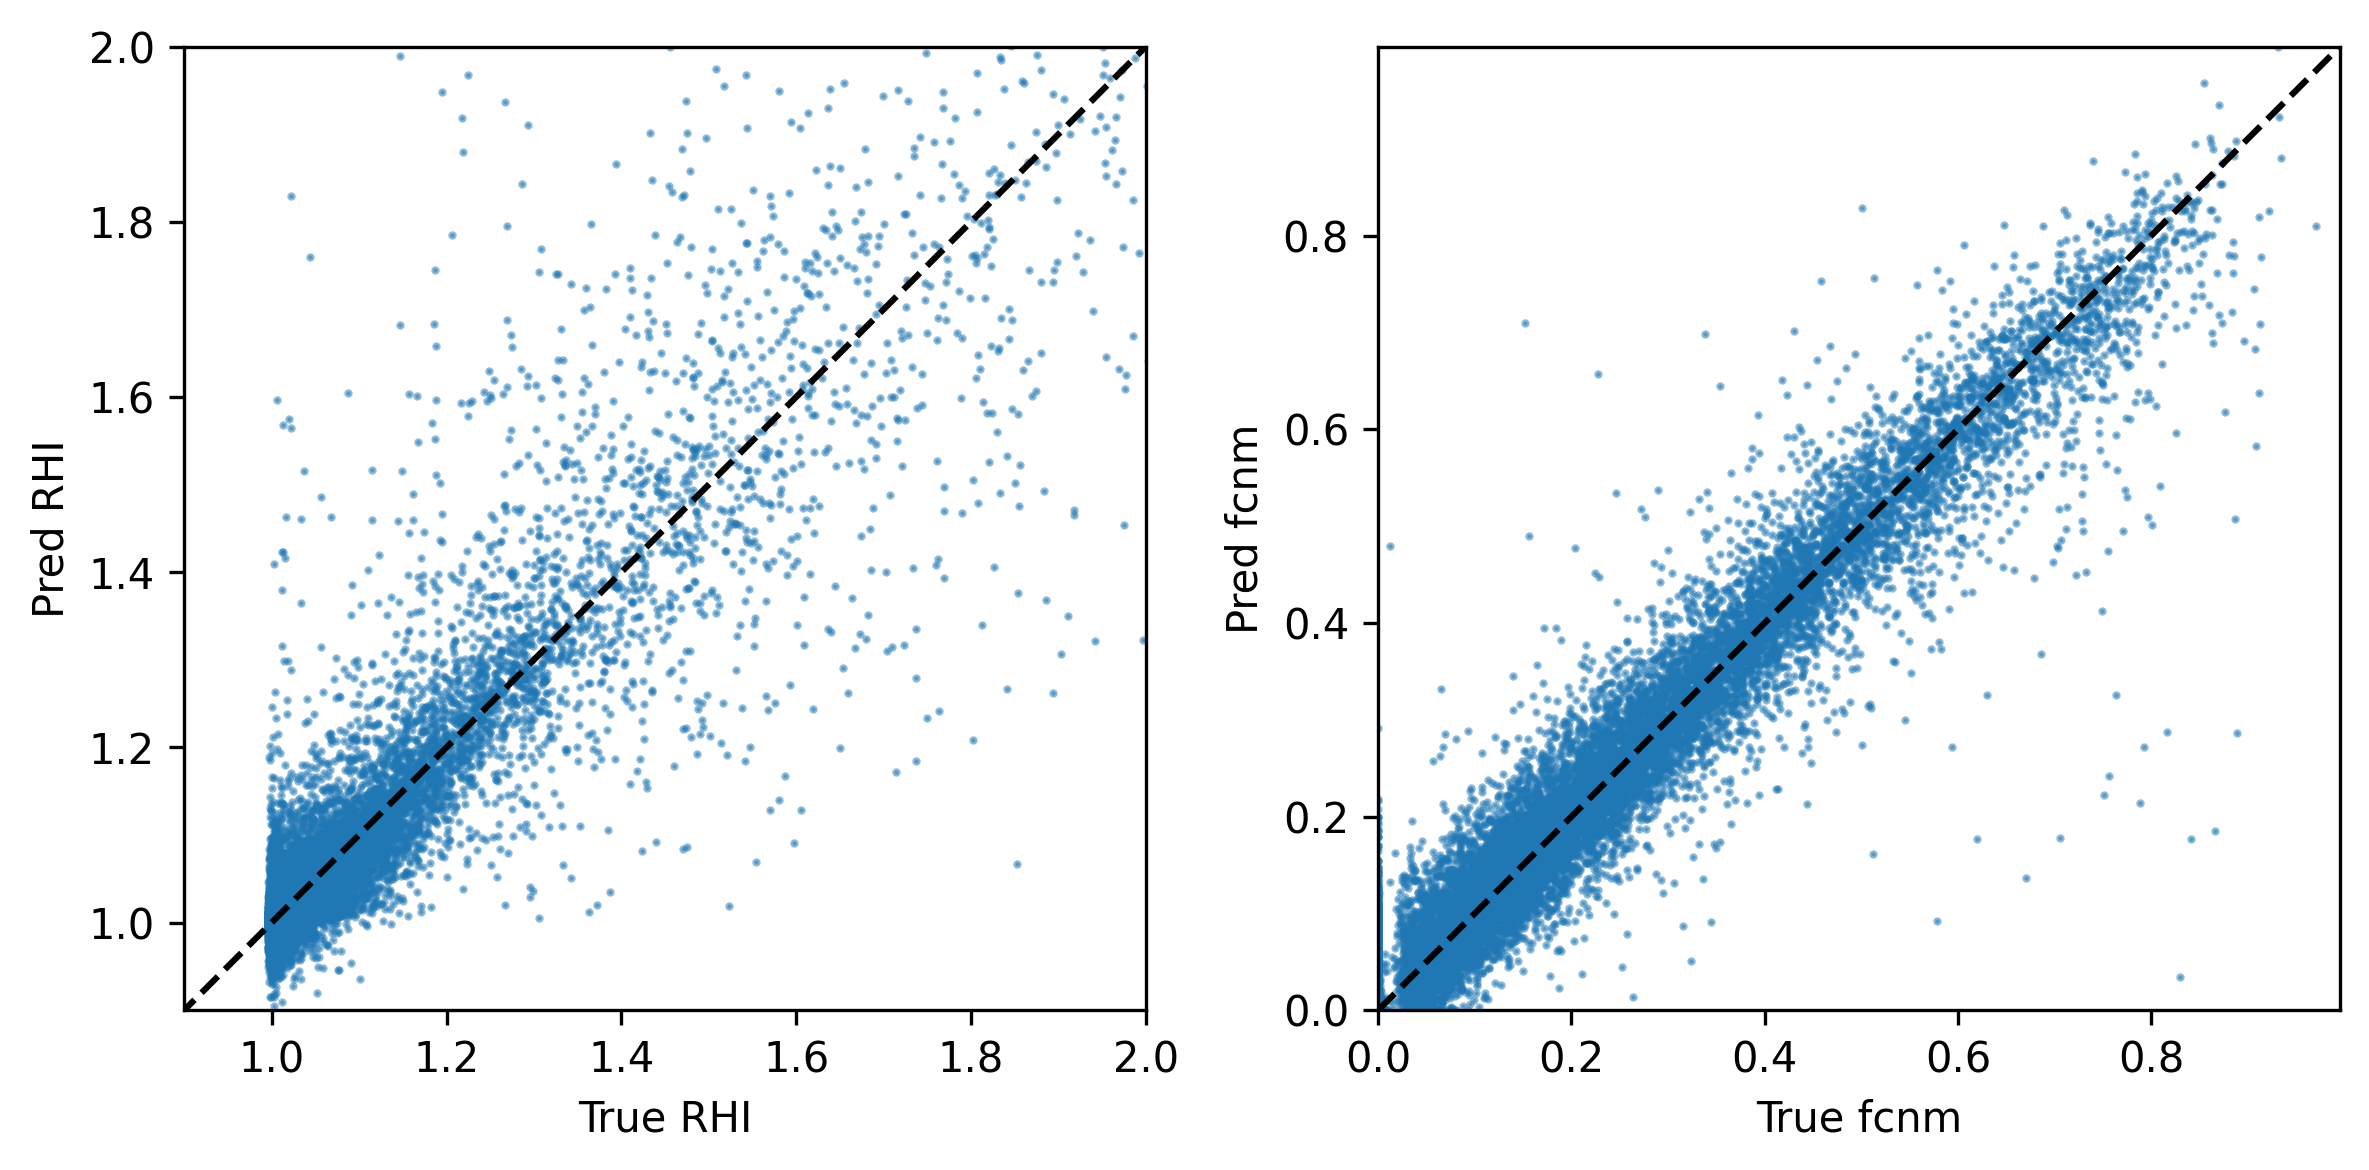

In [4]:
m1=pd.read_csv('layer_sweep_full_layers7/test_predictions_layers7.csv')
plt.figure(figsize=(8,4),dpi=300)
plt.subplot(121)
plt.scatter(m1['true_rhi'],m1['pred_rhi'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_rhi'].min(), m1['pred_rhi'].min())), float(max(m1['true_rhi'].max(), m1['pred_rhi'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True RHI")
plt.ylabel(f"Pred RHI")
plt.xlim(0.9, 2)
plt.ylim(0.9, 2)
#
plt.subplot(122)
plt.scatter(m1['true_fcnm'],m1['pred_fcnm'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_fcnm'].min(), m1['pred_fcnm'].min())), float(max(m1['true_fcnm'].max(), m1['pred_fcnm'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True fcnm")
plt.ylabel(f"Pred fcnm")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.tight_layout()

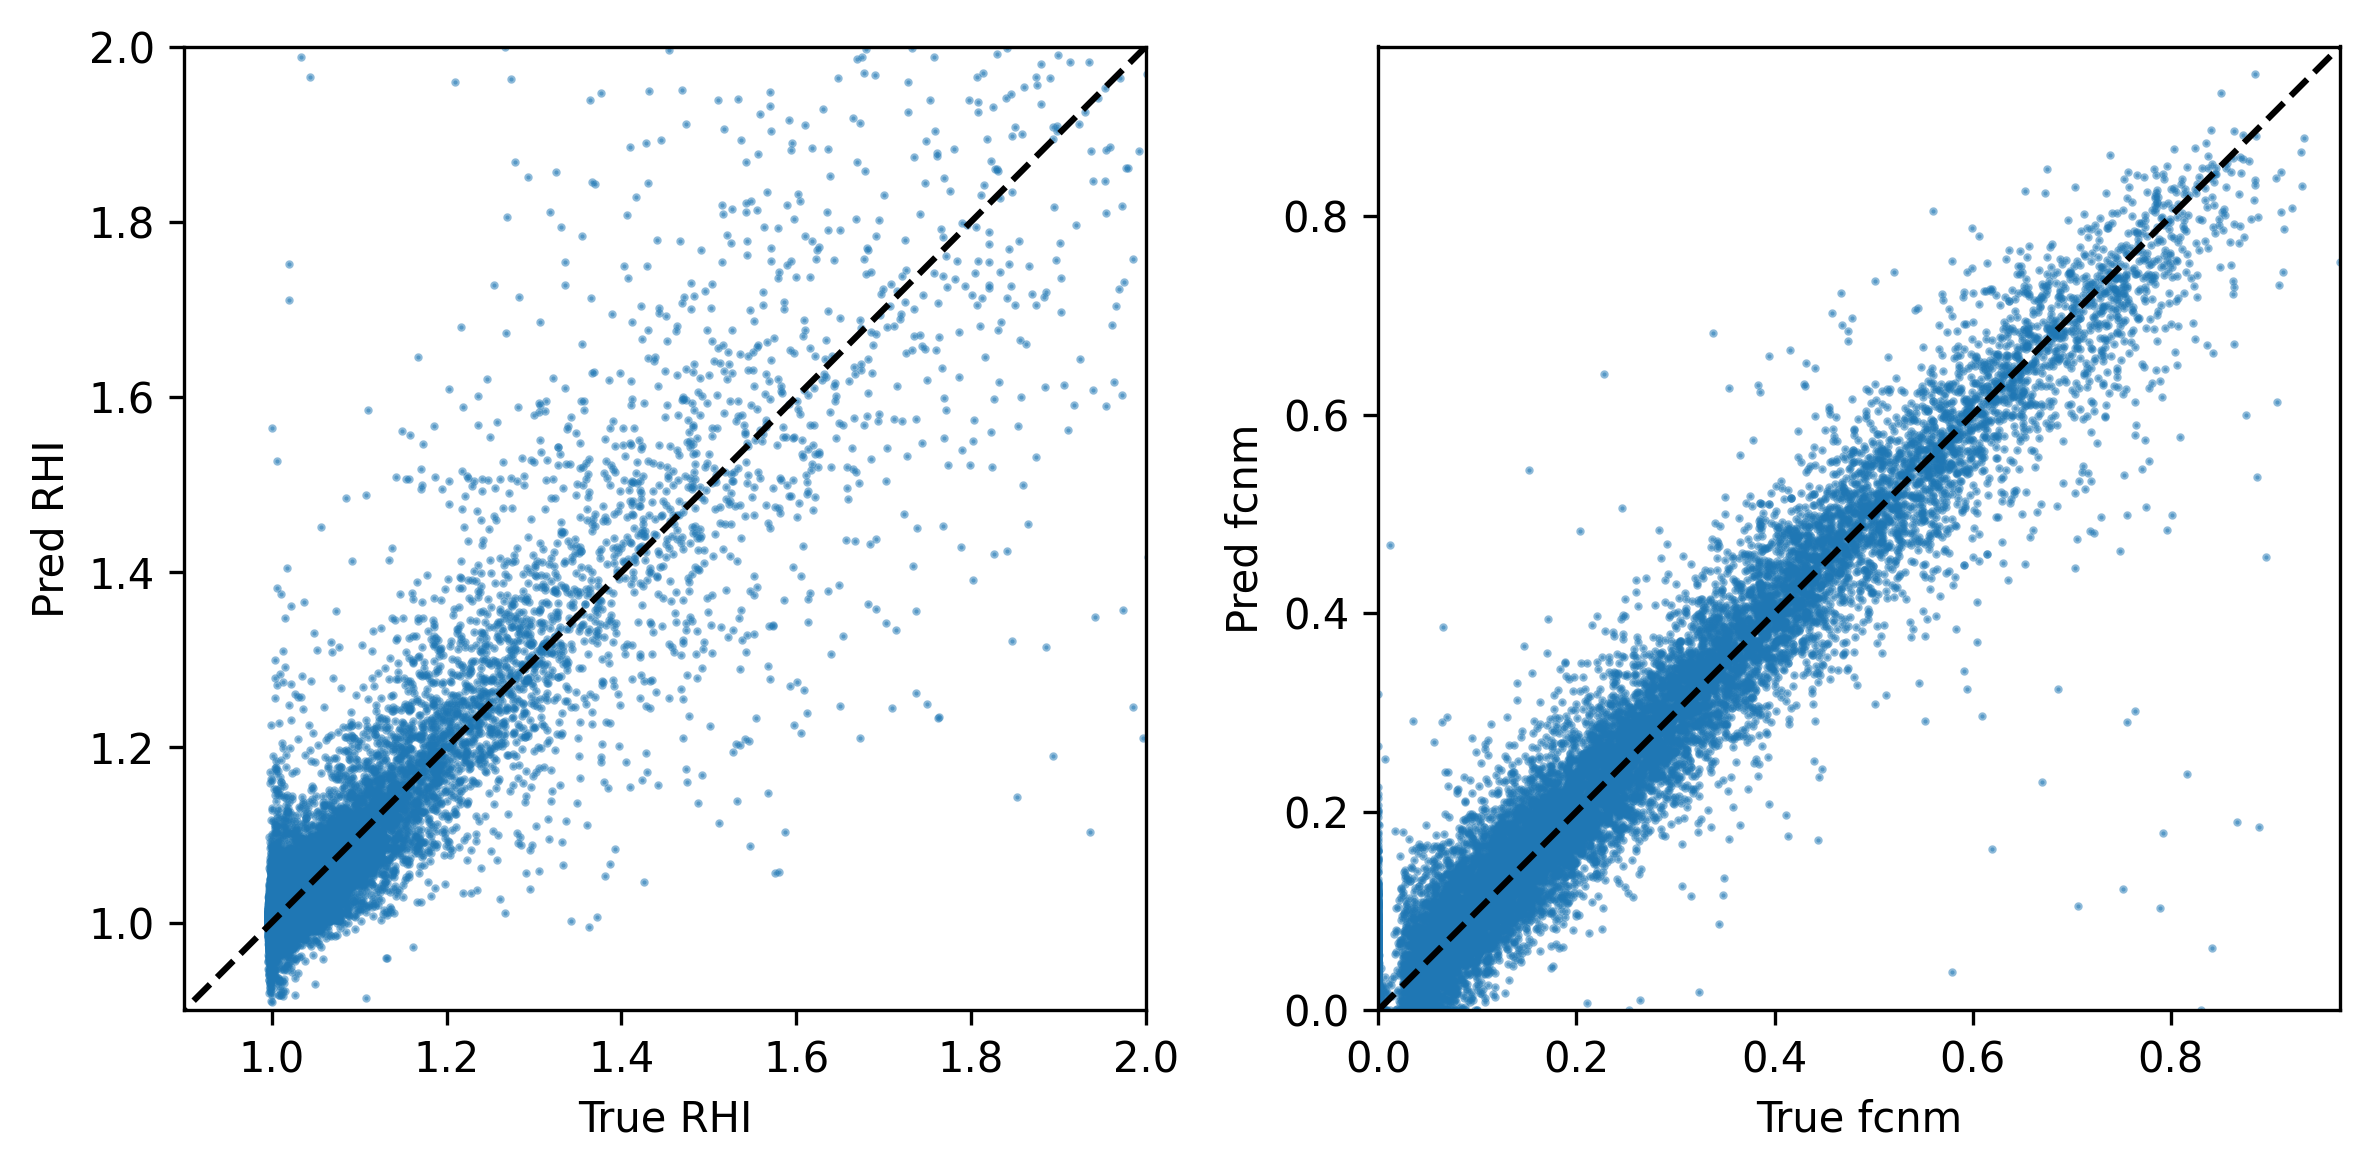

In [5]:
m1=pd.read_csv('layer_sweep_full_layers8/test_predictions_layers8.csv')
plt.figure(figsize=(8,4),dpi=300)
plt.subplot(121)
plt.scatter(m1['true_rhi'],m1['pred_rhi'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_rhi'].min(), m1['pred_rhi'].min())), float(max(m1['true_rhi'].max(), m1['pred_rhi'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True RHI")
plt.ylabel(f"Pred RHI")
plt.xlim(0.9, 2)
plt.ylim(0.9, 2)
#
plt.subplot(122)
plt.scatter(m1['true_fcnm'],m1['pred_fcnm'],s=1,alpha=0.5)
lo, hi = float(min(m1['true_fcnm'].min(), m1['pred_fcnm'].min())), float(max(m1['true_fcnm'].max(), m1['pred_fcnm'].max()))
plt.plot([lo, hi], [lo, hi],'k--')
plt.xlabel(f"True fcnm")
plt.ylabel(f"Pred fcnm")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.tight_layout()

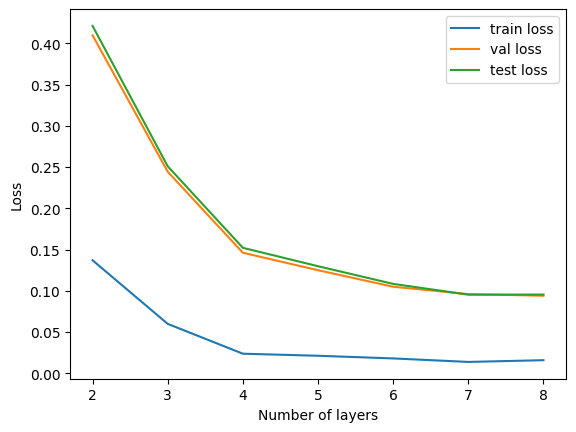

In [12]:
train_loss=[]
val_loss=[]
test_loss=[]
for i in range(1,8):
    m1=pd.read_csv(f'layer_sweep_full_layers{i+1}/training_metrics_layers{i+1}.csv')
    train_loss.append(m1['train_loss'][-10:-1].mean())
    val_loss.append(m1['val_loss'][-10:-1].mean())
    test_loss.append(m1['test_loss'][-10:-1].mean())

plt.plot(range(2,9), train_loss, label='train loss')
plt.plot(range(2,9), val_loss, label='val loss')
plt.plot(range(2,9), test_loss, label='test loss')
plt.xlabel('Number of layers')
plt.ylabel('Loss')
plt.legend()